In [1]:
import warnings
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "pyproject.toml").exists() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from typing import *

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from backtest.utils.build_dataset import create_dataset
from backtest.utils.evaluation import (
    compute_equity_curves,
    compute_portfolio_statistics,
    evaluate_experiments_classification,
    evaluate_experiments_topk,
    evaluate_experiments_topk_percent,
    evaluate_experiments_topk_percent_curves,
    get_btc_buy_and_hold_baseline,
    get_equity_curve_for_experiment,
    highlight_max,
    random_topk_baseline,
    select_best_experiment_on_validation,
)
from backtest.utils.graphs import (
    plot_bootstrap_ci,
    plot_classification_metrics,
    plot_equity_curves,
    plot_feature_distributions,
    plot_feature_importance_distribution,
    plot_impact_regression,
    plot_pnl_sensitivity,
    plot_robustness_distribution,
    plot_topk_accuracy,
    plot_topk_percent_curves,
)
from backtest.pipelines.BasePipeline import add_col_pump_id, cross_section_standardisation
from core.feature_type import FeatureType
from features.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset:   0%|          | 0/498 [00:00<?, ?it/s]

Building dataset:   7%|▋         | 36/498 [00:00<00:01, 320.38it/s]

Building dataset:  20%|██        | 101/498 [00:00<00:00, 481.23it/s]

Building dataset:  33%|███▎      | 163/498 [00:00<00:00, 524.82it/s]

Building dataset:  43%|████▎     | 216/498 [00:00<00:00, 522.07it/s]

...

Building dataset:  79%|███████▊  | 391/498 [00:00<00:00, 529.58it/s]

Building dataset:  91%|█████████ | 453/498 [00:00<00:00, 551.87it/s]

Building dataset: 100%|██████████| 498/498 [00:00<00:00, 546.62it/s]

2026-08-16 14:31:48,272 | WARNING | root | No data present for 25 pumps


2026-08-16 14:31:48,282 | INFO | root | Wrote 25 dropped pump events to /home/borokoko/dev/pumps_and_dumps/resources/dropped_pumps.json


<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

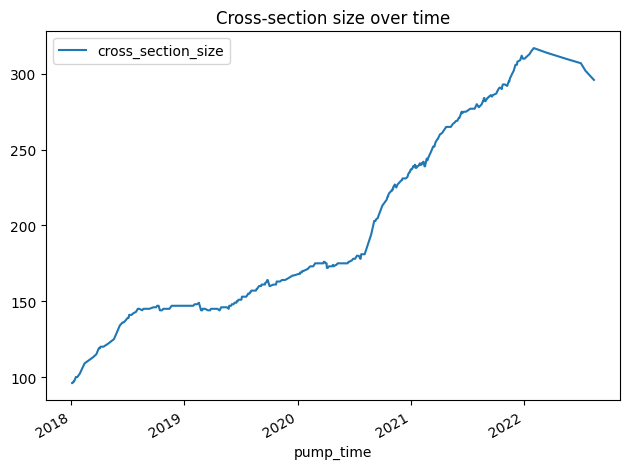

In [3]:
# cross-section statistics
ax = (
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
ax.figure.tight_layout()
ax.figure.savefig("images/cs_size.jpeg", dpi=300, bbox_inches="tight")
plt.show()

<h4>Feature distributions and preprocessing</h4>

<p>Inspect feature statistics, clip power-law values for this diagnostic view, and quantify missingness before model-specific handling.</p>

In [4]:
# Define feature column groups
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)

all_feature_cols = (
        powerlaw_cols + asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols
        + share_of_long_trades_cols + slippage_imbalance_cols + flow_imbalance_cols + num_trades_cols
)

# Clip power-law features to the model range; missing values remain explicit
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2)

# Summary statistics
print(f"Dataset shape: {df.shape}")
print(f"NaN rows remaining: {df[all_feature_cols].isna().any(axis=1).sum()}")
df[all_feature_cols].describe().T[["mean", "std", "min", "max"]]

Dataset shape: (92260, 91)
NaN rows remaining: 40852


,mean,std,min,max
powerlaw_alpha@5MIN,1.528390,0.293009,1.000000,2.0
powerlaw_alpha@15MIN,1.395293,0.229592,1.000000,2.0
powerlaw_alpha@1H,1.282588,0.131244,1.000000,2.0
powerlaw_alpha@2H,1.250920,0.103714,1.082472,2.0
powerlaw_alpha@4H,1.227763,0.088342,1.085151,2.0
...,...,...,...,...
num_trades@12H,4406.656547,11060.813342,0.000000,389425.0
num_trades@1D,8523.548298,21283.434286,3.000000,867720.0
num_trades@2D,17092.027964,41402.345632,28.000000,1309256.0
num_trades@7D,59910.770637,135381.180636,168.000000,3801007.0


<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [5]:
# Apply the same cross-sectional standardisation used by every model pipeline
df_scaled: pd.DataFrame = cross_section_standardisation(add_col_pump_id(df.copy()))
df_scaled.head(2)

,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped,pump_id
0,-0.662659,-0.799030,-0.459977,0.192308,-0.455235,-1.0,-0.848503,26,-0.980181,-1.183763,...,4.892368,19.569472,15.655577,17.612524,1INCH-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0
1,-0.430770,-0.510663,-0.447306,0.366667,-1.314539,-1.0,-0.410167,30,-0.098536,-0.129122,...,18.950728,29.922202,-0.997407,9.974067,AAVE-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0


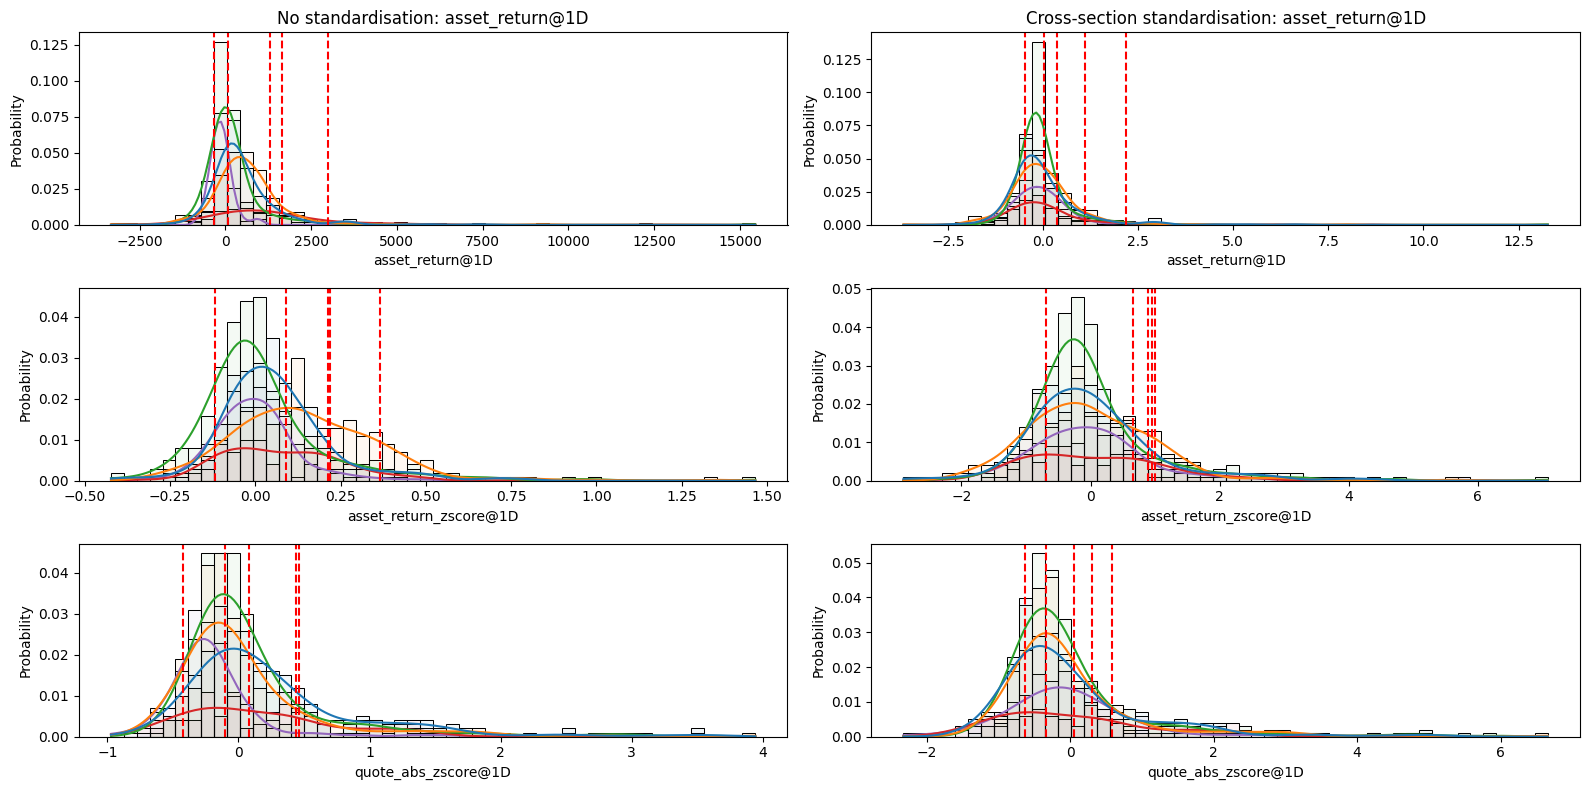

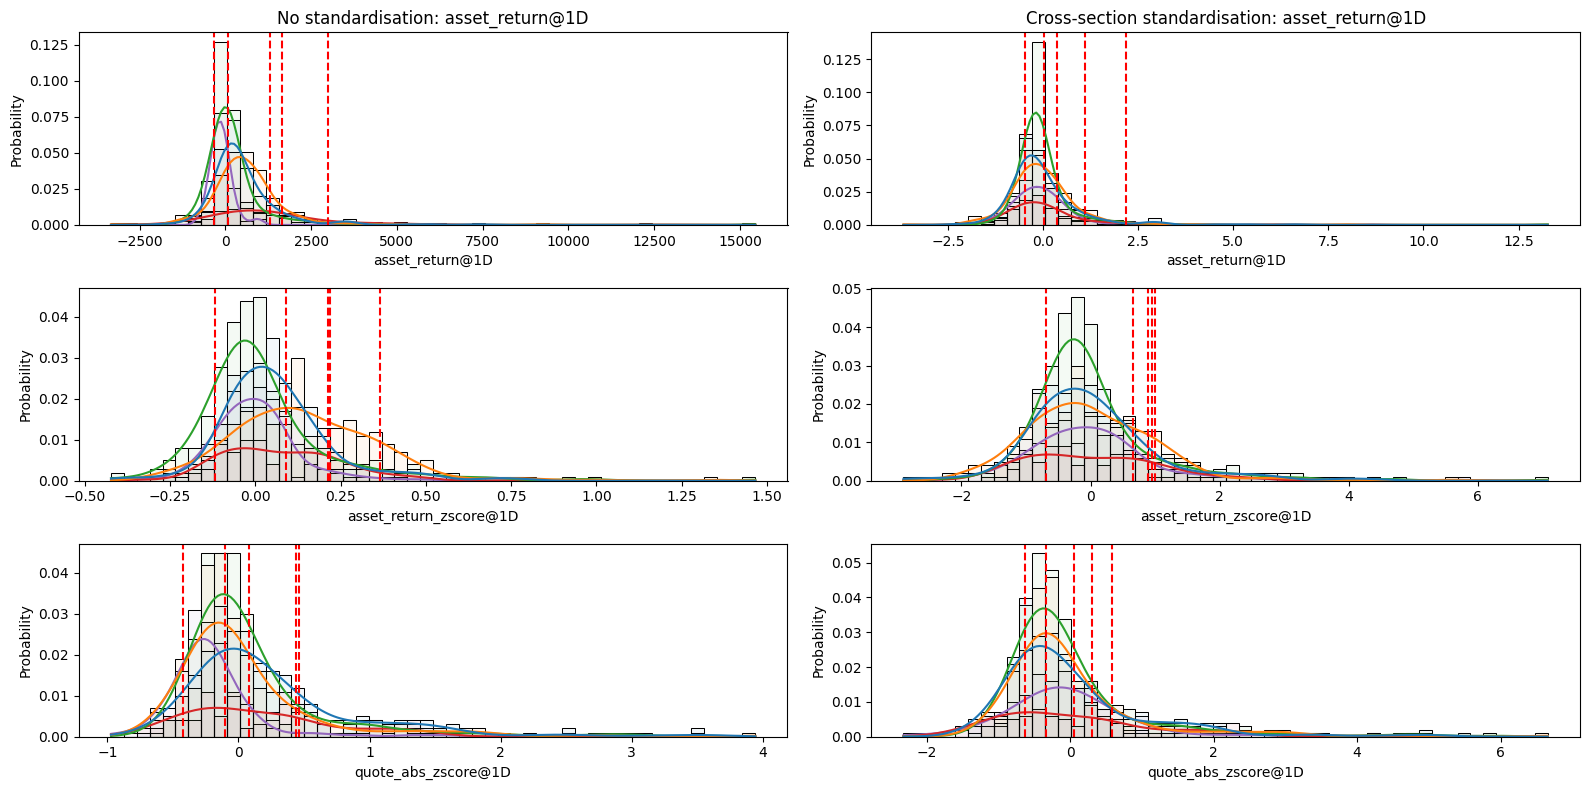

In [6]:
from core.time_utils import NamedTimeDelta

plot_feature_distributions(
    df_raw=df,
    df_scaled=df_scaled,
    feature_types=[FeatureType.ASSET_RETURN, FeatureType.ASSET_RETURN_ZSCORE, FeatureType.QUOTE_ABS_ZSCORE],
    offset=NamedTimeDelta.ONE_DAY,
    n_pumps=5,
    save_path="images/cs_standardization_impact.png",
)

<h4>Split data and train the first model</h4>

In [7]:
from backtest.utils.sample import Sample
from backtest.utils.feature_set import FeatureSet
from backtest.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>Logistic regression model</h4>

In [8]:
from backtest.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from backtest.pipelines.LogisticRegression.model import LogisticRegressionModel

pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="Logistic regression", model=model, sample=sample)

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="Logistic regression + Tuned", model=model, sample=sample)

2026-08-16 14:31:50,638 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:31:50,639 | INFO | root | Building raw dataset from feature files


Building dataset:   0%|          | 0/498 [00:00<?, ?it/s]

Building dataset:  11%|█         | 55/498 [00:00<00:00, 509.52it/s]

Building dataset:  26%|██▌       | 127/498 [00:00<00:00, 609.18it/s]

...

2026-08-16 14:31:52,101 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 92)


2026-08-16 14:31:52,126 | INFO | root | Training model


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


2026-08-16 14:31:53,533 | INFO | root | Training model


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


<h4>Random forest</h4>

In [9]:
from backtest.pipelines.RandomForest.pipe import RandomForestPipeline
from backtest.pipelines.RandomForest.model import RandomForestModel

pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="Random forest", model=model, sample=sample)

model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="Random forest + Tuned", model=model, sample=sample)

2026-08-16 14:31:54,228 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:31:54,228 | INFO | root | Using cached raw dataset


2026-08-16 14:31:54,464 | INFO | root | Nans
asset_return@5MIN     0
asset_return@15MIN    0
asset_return@1H       0
asset_return@2H       0
asset_return@4H       0
                     ..
num_trades@1D         0
num_trades@2D         0
num_trades@7D         0
num_trades@14D        0
num_prev_pump         0
Length: 81, dtype: int64


2026-08-16 14:31:54,686 | INFO | root | Dataset DatasetType.TRAIN. Shape (44868, 92)


2026-08-16 14:31:54,687 | INFO | root | Dataset DatasetType.VALIDATION. Shape (24377, 92)


2026-08-16 14:31:54,687 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 92)


2026-08-16 14:31:54,712 | INFO | root | Training model


2026-08-16 14:31:55,781 | INFO | root | Training model


<h4>CatBoost classifier</h4>

In [10]:
from backtest.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from backtest.pipelines.CatboostClassifier.model import CatboostClassifierModel

pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatBoost classifier", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatBoost classifier + Tuned", model=model, sample=sample)

2026-08-16 14:31:59,649 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:31:59,649 | INFO | root | Using cached raw dataset


2026-08-16 14:31:59,910 | INFO | root | Dataset DatasetType.TRAIN. Shape (44868, 92)


2026-08-16 14:31:59,910 | INFO | root | Dataset DatasetType.VALIDATION. Shape (24377, 92)


2026-08-16 14:31:59,911 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 92)


<h4>CatBoost classifier + SMOTE</h4>

In [11]:
from backtest.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatBoost classifier + SMOTE", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatBoost classifier + SMOTE + Tuned", model=model, sample=sample)

2026-08-16 14:32:00,750 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:32:00,751 | INFO | root | Using cached raw dataset


2026-08-16 14:32:01,390 | INFO | root | Nans
asset_return@5MIN     0
asset_return@15MIN    0
asset_return@1H       0
asset_return@2H       0
asset_return@4H       0
                     ..
num_trades@1D         0
num_trades@2D         0
num_trades@7D         0
num_trades@14D        0
num_prev_pump         0
Length: 81, dtype: int64


2026-08-16 14:32:01,419 | INFO | root | Dataset DatasetType.TRAIN. Shape (44868, 92)


2026-08-16 14:32:01,419 | INFO | root | Dataset DatasetType.VALIDATION. Shape (24377, 92)


2026-08-16 14:32:01,419 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 92)


2026-08-16 14:32:01,456 | INFO | root | Applying SMOTE


<h4>CatBoost ranker</h4>
<p>The ranker uses the realized five-minute post-announcement return as supervision, ordered highest-first within each event cross-section. The first ordinal position is therefore the asset with the highest realized return; only pre-decision features are supplied as regressors.</p>

In [12]:
from backtest.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from backtest.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatBoost ranker", model=model, sample=sample)

model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatBoost ranker + Tuned", model=model, sample=sample)

2026-08-16 14:32:07,008 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:32:07,008 | INFO | root | Using cached raw dataset


2026-08-16 14:32:07,313 | INFO | root | Dataset DatasetType.TRAIN. Shape (44868, 93)


2026-08-16 14:32:07,314 | INFO | root | Dataset DatasetType.VALIDATION. Shape (24377, 93)


2026-08-16 14:32:07,314 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 93)


2026-08-16 14:32:08,775 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatBoost classifier + Top@k%AUC early stopping</h4>

In [13]:
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkpauc_tuned = Experiment(experiment_name="CatBoost classifier + Top@k%AUC early stopping", model=model,
                                         sample=sample)

2026-08-16 14:32:12,340 | INFO | root | Building dataset and preprocessing data


2026-08-16 14:32:12,341 | INFO | root | Using cached raw dataset


2026-08-16 14:32:12,688 | INFO | root | Dataset DatasetType.TRAIN. Shape (44868, 92)


2026-08-16 14:32:12,688 | INFO | root | Dataset DatasetType.VALIDATION. Shape (24377, 92)


2026-08-16 14:32:12,689 | INFO | root | Dataset DatasetType.TEST. Shape (23015, 92)


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Can't optimze method "evaluate" because self argument is used
  _check_train_params(params)


0:	learn: 0.3489224	test: 0.4765777	best: 0.4765777 (0)	total: 266ms	remaining: 4m 26s
10:	learn: 0.4954741	test: 0.6128641	best: 0.6186893 (8)	total: 300ms	remaining: 27s
20:	learn: 0.5467672	test: 0.6427184	best: 0.6427184 (20)	total: 338ms	remaining: 15.8s
30:	learn: 0.5659483	test: 0.6469660	best: 0.6519417 (28)	total: 376ms	remaining: 11.7s
40:	learn: 0.5786207	test: 0.6485437	best: 0.6520631 (36)	total: 414ms	remaining: 9.69s
50:	learn: 0.5965086	test: 0.6552184	best: 0.6552184 (50)	total: 452ms	remaining: 8.4s


60:	learn: 0.6038362	test: 0.6652913	best: 0.6655340 (56)	total: 489ms	remaining: 7.53s
70:	learn: 0.6100431	test: 0.6645631	best: 0.6665049 (62)	total: 528ms	remaining: 6.9s
80:	learn: 0.6212500	test: 0.6662621	best: 0.6674757 (77)	total: 565ms	remaining: 6.41s
90:	learn: 0.6315086	test: 0.6592233	best: 0.6674757 (77)	total: 604ms	remaining: 6.03s
100:	learn: 0.6413362	test: 0.6540049	best: 0.6674757 (77)	total: 642ms	remaining: 5.71s
110:	learn: 0.6507328	test: 0.6518204	best: 0.6674757 (77)	total: 680ms	remaining: 5.45s


120:	learn: 0.6671983	test: 0.6506068	best: 0.6674757 (77)	total: 720ms	remaining: 5.23s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6674757282
bestIteration = 77

Shrink model to first 78 iterations.


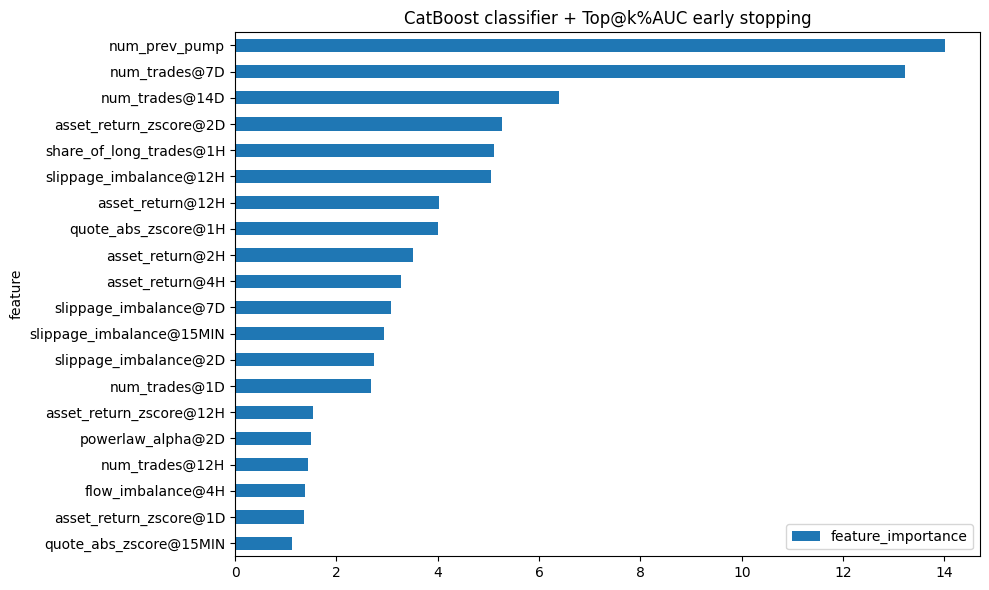

In [14]:
model = experiment_cb_topkpauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatBoost classifier + Top@k%AUC early stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h3>Validation metrics and model selection</h3>
<p>All candidate models are compared on the validation split using Top@k, Top@k%, Top@k%AUC, PR-AUC, F1, and balanced accuracy. The final model is selected by validation Top@k%AUC only; the test split remains sealed until the following section.</p>

In [15]:
from backtest.utils.sample import DatasetType
from backtest.utils.experiment import Experiment

experiments: List[Experiment] = [
    experiment_lr, experiment_lr_tuned,
    experiment_rf, experiment_rf_tuned,
    experiment_cb, experiment_cb_tuned,
    experiment_cb_smote, experiment_cb_smote_tuned,
    experiment_cb_ranker, experiment_cb_ranker_tuned,
    experiment_cb_topkpauc_tuned,
]

cols = [col for col in [experiment.get_experiment_name() for experiment in experiments] if col.endswith("Tuned")] + [
    "CatBoost classifier + Top@k%AUC early stopping"
]

In [16]:
df_topk_validation = evaluate_experiments_topk(experiments, dataset_type=DatasetType.VALIDATION)
styled_validation_topk = df_topk_validation.T.style.apply(highlight_max, axis=0).format("{:.4f}")
styled_validation_topk

Top@k (VALIDATION):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k (VALIDATION):   9%|▉         | 1/11 [00:00<00:01,  7.50it/s]

Top@k (VALIDATION):  18%|█▊        | 2/11 [00:00<00:01,  7.69it/s]

Top@k (VALIDATION):  27%|██▋       | 3/11 [00:00<00:01,  7.58it/s]

Top@k (VALIDATION):  36%|███▋      | 4/11 [00:00<00:00,  7.16it/s]

Top@k (VALIDATION):  55%|█████▍    | 6/11 [00:00<00:00, 10.46it/s]

Top@k (VALIDATION):  73%|███████▎  | 8/11 [00:00<00:00, 12.61it/s]

Top@k (VALIDATION):  91%|█████████ | 10/11 [00:00<00:00, 14.23it/s]

Top@k (VALIDATION): 100%|██████████| 11/11 [00:00<00:00, 11.66it/s]

,1,2,3,5,10,20,30
Logistic regression,0.1359,0.1845,0.2427,0.3398,0.4757,0.6214,0.6796
Logistic regression + Tuned,0.1068,0.1748,0.2233,0.3010,0.4854,0.6505,0.7379
Random forest,0.1650,0.2233,0.2427,0.2816,0.3981,0.5340,0.5922
Random forest + Tuned,0.1748,0.2621,0.3301,0.3981,0.4854,0.6602,0.7379
CatBoost classifier,0.1650,0.2330,0.2913,0.3495,0.5049,0.6408,0.6990
CatBoost classifier + Tuned,0.1650,0.2524,0.3010,0.4175,0.5243,0.6699,0.7379
CatBoost classifier + SMOTE,0.0777,0.0971,0.1359,0.1650,0.2621,0.3689,0.4757
CatBoost classifier + SMOTE + Tuned,0.1068,0.2136,0.2330,0.3204,0.4369,0.4951,0.6019
CatBoost ranker,0.0874,0.1748,0.2621,0.3592,0.4369,0.5049,0.5534
CatBoost ranker + Tuned,0.1068,0.1553,0.2233,0.3010,0.4660,0.5728,0.6311


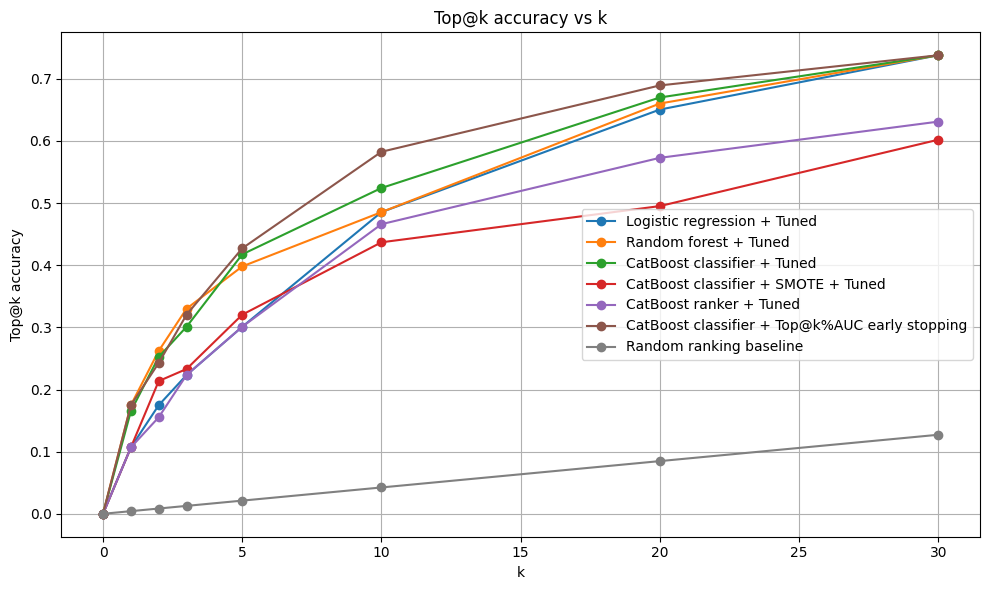

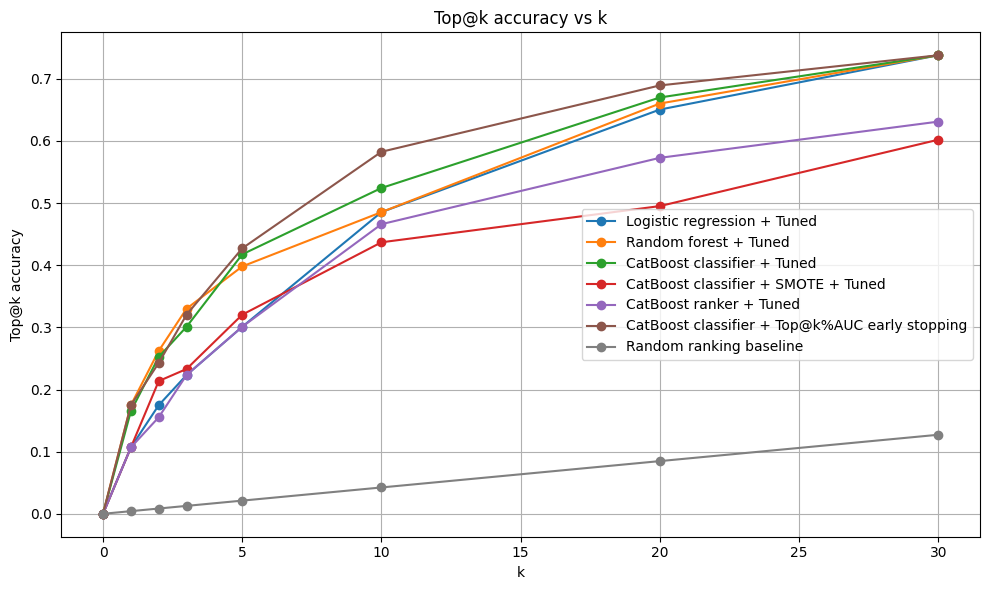

In [17]:
validation_sample = experiments[0].get_sample().get_dataset(DatasetType.VALIDATION)
validation_random_baseline = random_topk_baseline(validation_sample)

plot_topk_accuracy(
    df_topk_validation,
    cols=cols,
    random_baseline=validation_random_baseline,
    save_path="images/topk_accuracy_validation.png",
)

<h4>Validation Top@k%</h4>

In [18]:
df_topkp_validation = evaluate_experiments_topk_percent(
    experiments, dataset_type=DatasetType.VALIDATION
)
styled_validation_topkp = df_topkp_validation.style.apply(highlight_max, axis=1).format("{:.4f}")
styled_validation_topkp

Top@k% (VALIDATION):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k% (VALIDATION):   9%|▉         | 1/11 [00:00<00:01,  8.34it/s]

Top@k% (VALIDATION):  18%|█▊        | 2/11 [00:00<00:01,  7.73it/s]

Top@k% (VALIDATION):  27%|██▋       | 3/11 [00:00<00:01,  7.70it/s]

Top@k% (VALIDATION):  36%|███▋      | 4/11 [00:00<00:00,  7.41it/s]

Top@k% (VALIDATION):  64%|██████▎   | 7/11 [00:00<00:00, 12.36it/s]

Top@k% (VALIDATION):  91%|█████████ | 10/11 [00:00<00:00, 15.28it/s]

Top@k% (VALIDATION): 100%|██████████| 11/11 [00:00<00:00, 12.66it/s]

,Logistic regression,Logistic regression + Tuned,Random forest,Random forest + Tuned,CatBoost classifier,CatBoost classifier + Tuned,CatBoost classifier + SMOTE,CatBoost classifier + SMOTE + Tuned,CatBoost ranker,CatBoost ranker + Tuned,CatBoost classifier + Top@k%AUC early stopping
0.010000,0.2427,0.2233,0.2427,0.3301,0.2913,0.3010,0.1359,0.2330,0.2621,0.2233,0.3204
0.020000,0.3398,0.3107,0.2913,0.3981,0.3495,0.4272,0.1650,0.3204,0.3592,0.3107,0.4272
0.050000,0.4951,0.5631,0.4272,0.5340,0.5437,0.5922,0.2718,0.4563,0.4660,0.4757,0.6408
0.100000,0.6602,0.6796,0.5631,0.6893,0.6699,0.7087,0.4175,0.5437,0.5243,0.6019,0.7184
0.200000,0.7864,0.7670,0.6893,0.7767,0.7670,0.8058,0.5631,0.6990,0.6311,0.7184,0.8155
0.500000,0.9417,0.9417,0.8835,0.9320,0.9515,0.9709,0.8544,0.8738,0.9029,0.8544,0.9709


<h4>Validation Top@k% curves, Top@k%AUC, and final model selection</h4>

Top@k% curves (VALIDATION):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k% curves (VALIDATION):   9%|▉         | 1/11 [00:00<00:04,  2.44it/s]

Top@k% curves (VALIDATION):  18%|█▊        | 2/11 [00:00<00:03,  2.42it/s]

Top@k% curves (VALIDATION):  27%|██▋       | 3/11 [00:01<00:03,  2.39it/s]

Top@k% curves (VALIDATION):  36%|███▋      | 4/11 [00:01<00:03,  2.33it/s]

...

Top@k% curves (VALIDATION):  91%|█████████ | 10/11 [00:03<00:00,  3.58it/s]

Top@k% curves (VALIDATION): 100%|██████████| 11/11 [00:03<00:00,  3.63it/s]

Top@k% curves (VALIDATION): 100%|██████████| 11/11 [00:03<00:00,  3.10it/s]

Selected on validation: CatBoost classifier + Top@k%AUC early stopping


,Top@k%AUC
CatBoost classifier + Top@k%AUC early stopping,0.6675
CatBoost classifier + Tuned,0.6552
Random forest + Tuned,0.6277
Logistic regression + Tuned,0.6159
CatBoost classifier,0.6154
Logistic regression,0.5977
CatBoost ranker + Tuned,0.5505
Random forest,0.5242
CatBoost classifier + SMOTE + Tuned,0.5235
CatBoost ranker,0.4979


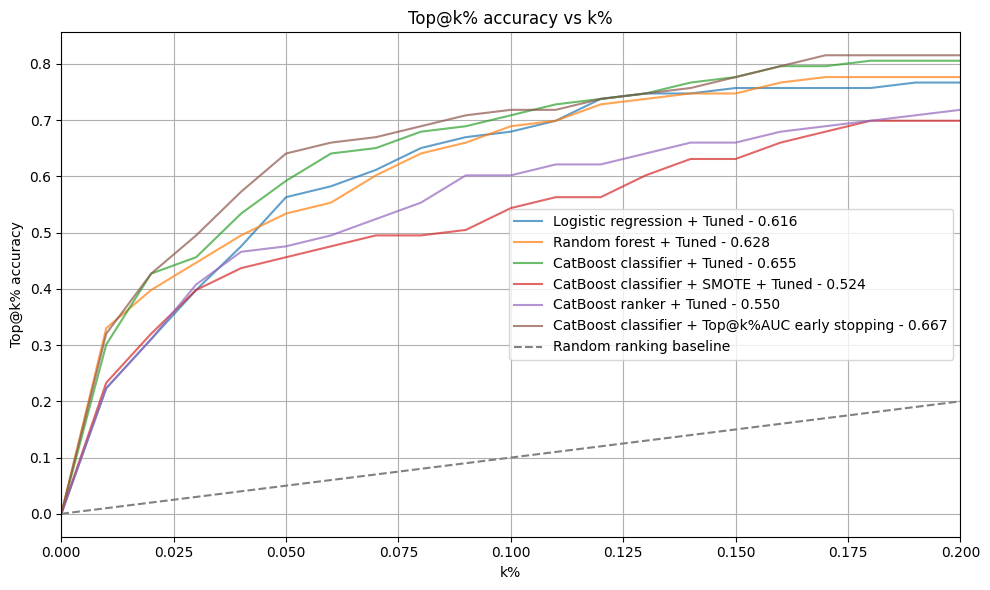

In [19]:
df_topkp_curves_validation, auc_scores_validation = evaluate_experiments_topk_percent_curves(
    experiments, dataset_type=DatasetType.VALIDATION
)
plot_topk_percent_curves(
    df_topkp_curves_validation,
    cols=cols,
    auc_scores=auc_scores_validation,
    save_path="images/topkp_auc_validation.png",
)
selected_experiment, validation_auc_ranking = select_best_experiment_on_validation(experiments)
selection_summary = validation_auc_ranking.rename("Top@k%AUC").to_frame()
print(f"Selected on validation: {selected_experiment.get_experiment_name()}")
selection_summary.style.apply(highlight_max, axis=0).format("{:.4f}")

<h4>Classification metrics on validation</h4>
<p>Alongside ranking metrics, we also report PR-AUC, F1, and balanced accuracy. For F1 and balanced accuracy, the decision rule selects Top@1 within each cross-section.</p>

In [20]:
df_classification_validation = evaluate_experiments_classification(
    experiments, dataset_type=DatasetType.VALIDATION
)
styled_validation_classification = df_classification_validation.style.apply(highlight_max, axis=0).format("{:.4f}")
styled_validation_classification

Classification metrics (VALIDATION):   0%|          | 0/11 [00:00<?, ?it/s]

Classification metrics (VALIDATION):   9%|▉         | 1/11 [00:00<00:02,  4.47it/s]

Classification metrics (VALIDATION):  18%|█▊        | 2/11 [00:00<00:02,  4.07it/s]

Classification metrics (VALIDATION):  27%|██▋       | 3/11 [00:00<00:02,  3.90it/s]

Classification metrics (VALIDATION):  36%|███▋      | 4/11 [00:01<00:01,  3.71it/s]

Classification metrics (VALIDATION): 100%|██████████| 11/11 [00:01<00:00, 15.03it/s]

Classification metrics (VALIDATION): 100%|██████████| 11/11 [00:01<00:00,  9.57it/s]

,PR-AUC,F1 (Top@1 per cross-section),Balanced Accuracy (Top@1 per cross-section)
Model,,,
Logistic regression,0.0743,0.1359,0.5661
Logistic regression + Tuned,0.0586,0.1068,0.5515
Random forest,0.0520,0.1650,0.5808
Random forest + Tuned,0.0849,0.1748,0.5856
CatBoost classifier,0.0796,0.1650,0.5808
CatBoost classifier + Tuned,0.0875,0.1650,0.5808
CatBoost classifier + SMOTE,0.0301,0.0777,0.5369
CatBoost classifier + SMOTE + Tuned,0.0600,0.1068,0.5515
CatBoost ranker,0.0571,0.0874,0.5418


,Top@k\%AUC,Top@1,Top@5,Top@10,Top@1\%,Top@5\%,Top@10\%,PR-AUC,F1,Balanced accuracy
CatBoost classifier + Top@k\%AUC early stopping,0.667,0.175,0.427,0.583,0.320,0.641,0.718,0.098,0.175,0.586
CatBoost classifier + Tuned,0.655,0.165,0.417,0.524,0.301,0.592,0.709,0.087,0.165,0.581
Random forest + Tuned,0.628,0.175,0.398,0.485,0.330,0.534,0.689,0.085,0.175,0.586
Logistic regression + Tuned,0.616,0.107,0.301,0.485,0.223,0.563,0.680,0.059,0.107,0.552
CatBoost classifier,0.615,0.165,0.350,0.505,0.291,0.544,0.670,0.080,0.165,0.581
Logistic regression,0.598,0.136,0.340,0.476,0.243,0.495,0.660,0.074,0.136,0.566
CatBoost ranker + Tuned,0.550,0.107,0.301,0.466,0.223,0.476,0.602,0.048,0.107,0.552
Random forest,0.524,0.165,0.282,0.398,0.243,0.427,0.563,0.052,0.165,0.581
CatBoost classifier + SMOTE + Tuned,0.524,0.107,0.320,0.437,0.233,0.456,0.544,0.060,0.107,0.552
CatBoost ranker,0.498,0.087,0.359,0.437,0.262,0.466,0.524,0.057,0.087,0.542


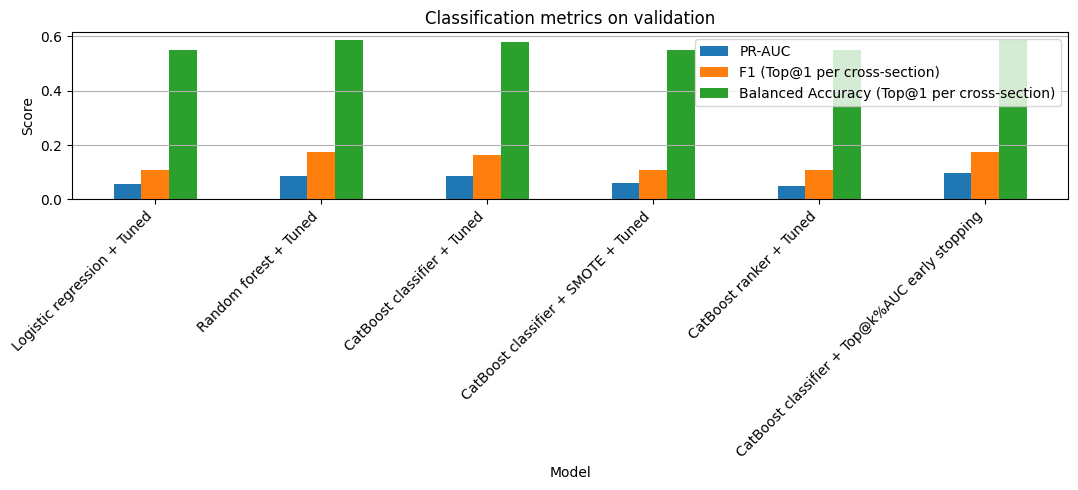

In [21]:
plot_classification_metrics(
    df_classification_validation,
    cols=cols,
    title="Classification metrics on validation",
    save_path="images/classification_metrics_validation.png",
)

validation_metrics_table = pd.DataFrame(index=validation_auc_ranking.index)
validation_metrics_table["Top@k%AUC"] = validation_auc_ranking
topk_validation_by_model = df_topk_validation.T
topkp_validation_by_model = df_topkp_validation.T
for k in (1, 5, 10):
    validation_metrics_table[f"Top@{k}"] = topk_validation_by_model[k]
for fraction, label in ((0.01, "Top@1%"), (0.05, "Top@5%"), (0.10, "Top@10%")):
    validation_metrics_table[label] = topkp_validation_by_model[fraction]
for metric in ("PR-AUC", "F1 (Top@1 per cross-section)", "Balanced Accuracy (Top@1 per cross-section)"):
    validation_metrics_table[metric] = df_classification_validation[metric]
validation_metrics_table = validation_metrics_table.rename(
    columns={
        "F1 (Top@1 per cross-section)": "F1",
        "Balanced Accuracy (Top@1 per cross-section)": "Balanced accuracy",
    }
)
validation_metrics_styled = (
    validation_metrics_table.style
    .format("{:.3f}", escape="latex")
    .format_index(escape="latex", axis=0)
    .format_index(escape="latex", axis=1)
    .highlight_max(axis=0, props="font-weight: bold;")
)
validation_metrics_styled

<h3>Final test-set evaluation</h3>
<p>The model choice above is now frozen. These Top@k, Top@k%, Top@k%AUC, and classification results are final holdout estimates and do not feed back into model selection.</p>

In [22]:
df_topk_test = evaluate_experiments_topk(experiments, dataset_type=DatasetType.TEST)
styled_test_topk = df_topk_test.T.style.apply(highlight_max, axis=0).format("{:.4f}")
styled_test_topk

Top@k (TEST):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k (TEST):   9%|▉         | 1/11 [00:00<00:01,  8.91it/s]

Top@k (TEST):  18%|█▊        | 2/11 [00:00<00:01,  8.00it/s]

Top@k (TEST):  27%|██▋       | 3/11 [00:00<00:00,  8.20it/s]

Top@k (TEST):  36%|███▋      | 4/11 [00:00<00:00,  7.94it/s]

Top@k (TEST):  64%|██████▎   | 7/11 [00:00<00:00, 13.29it/s]

Top@k (TEST):  91%|█████████ | 10/11 [00:00<00:00, 16.41it/s]

Top@k (TEST): 100%|██████████| 11/11 [00:00<00:00, 13.54it/s]

,1,2,3,5,10,20,30
Logistic regression,0.1125,0.1500,0.2125,0.3875,0.5500,0.6625,0.7000
Logistic regression + Tuned,0.1000,0.2000,0.2750,0.4250,0.5750,0.7000,0.7625
Random forest,0.0750,0.1250,0.1875,0.2750,0.3625,0.5750,0.6750
Random forest + Tuned,0.1125,0.1750,0.2750,0.3500,0.5000,0.6500,0.7125
CatBoost classifier,0.1125,0.1750,0.3125,0.3875,0.4625,0.5750,0.6875
CatBoost classifier + Tuned,0.1375,0.2750,0.3125,0.4000,0.5250,0.6500,0.7250
CatBoost classifier + SMOTE,0.0625,0.0875,0.1000,0.1500,0.2125,0.3125,0.4000
CatBoost classifier + SMOTE + Tuned,0.1125,0.1625,0.2250,0.3000,0.4250,0.5375,0.6000
CatBoost ranker,0.1000,0.1375,0.2000,0.2875,0.3625,0.5375,0.6250
CatBoost ranker + Tuned,0.0625,0.1625,0.1750,0.2750,0.4625,0.6125,0.7000


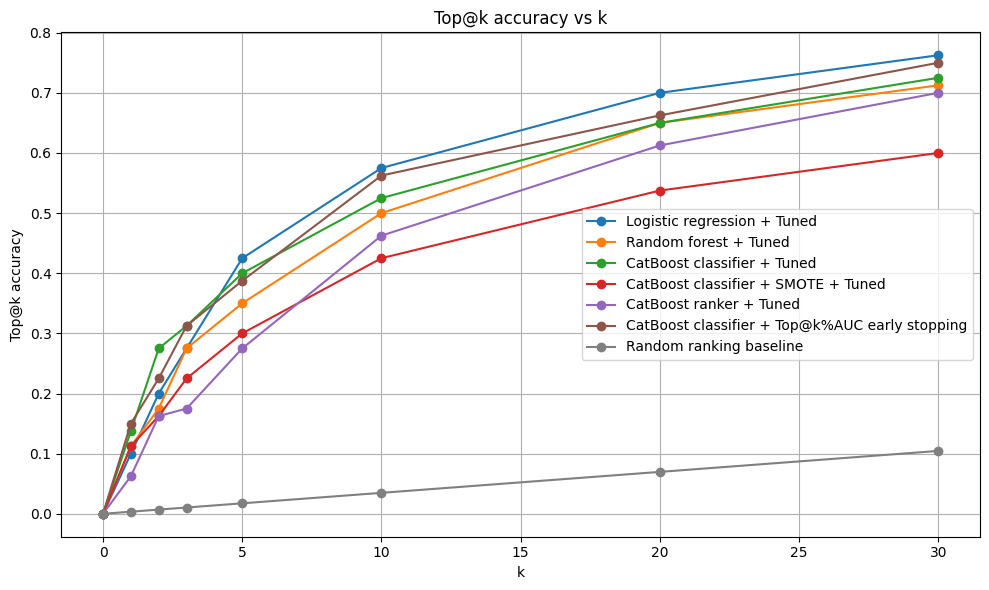

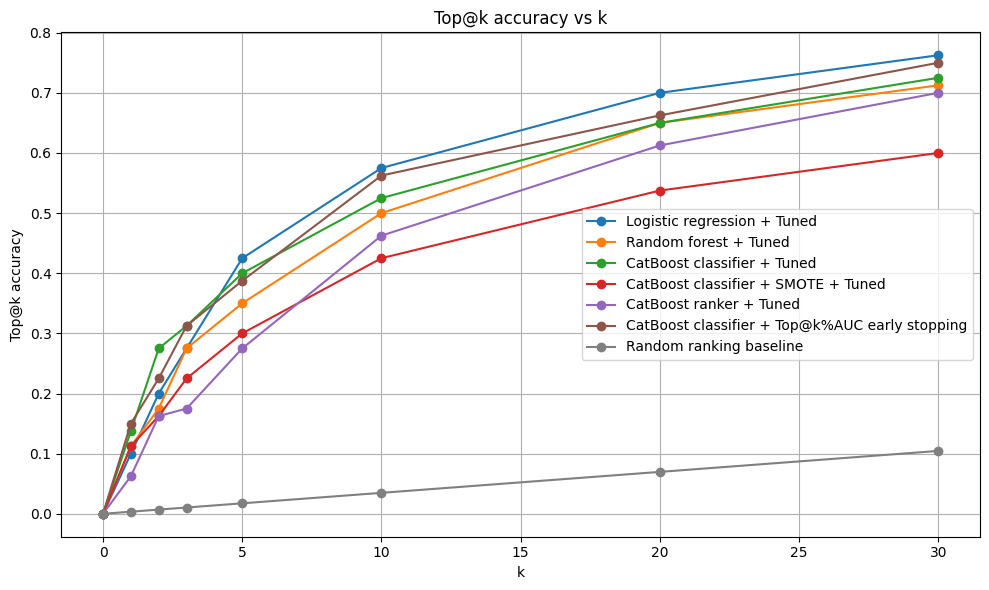

In [23]:
test_sample = experiments[0].get_sample().get_dataset(DatasetType.TEST)
test_random_baseline = random_topk_baseline(test_sample)
plot_topk_accuracy(
    df_topk_test,
    cols=cols,
    random_baseline=test_random_baseline,
    save_path="images/topk_accuracy_test.png",
)

<h4>Test Top@k%, Top@k% curves, and Top@k%AUC</h4>

In [24]:
df_topkp_test = evaluate_experiments_topk_percent(experiments, dataset_type=DatasetType.TEST)
styled_test_topkp = df_topkp_test.style.apply(highlight_max, axis=1).format("{:.4f}")
styled_test_topkp

Top@k% (TEST):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k% (TEST):   9%|▉         | 1/11 [00:00<00:01,  8.87it/s]

Top@k% (TEST):  18%|█▊        | 2/11 [00:00<00:00,  9.01it/s]

Top@k% (TEST):  27%|██▋       | 3/11 [00:00<00:00,  8.82it/s]

Top@k% (TEST):  36%|███▋      | 4/11 [00:00<00:00,  8.40it/s]

Top@k% (TEST):  64%|██████▎   | 7/11 [00:00<00:00, 14.23it/s]

Top@k% (TEST):  91%|█████████ | 10/11 [00:00<00:00, 17.74it/s]

Top@k% (TEST): 100%|██████████| 11/11 [00:00<00:00, 14.61it/s]

,Logistic regression,Logistic regression + Tuned,Random forest,Random forest + Tuned,CatBoost classifier,CatBoost classifier + Tuned,CatBoost classifier + SMOTE,CatBoost classifier + SMOTE + Tuned,CatBoost ranker,CatBoost ranker + Tuned,CatBoost classifier + Top@k%AUC early stopping
0.010000,0.2750,0.3250,0.1875,0.2750,0.3250,0.3375,0.1125,0.2375,0.2000,0.2000,0.3125
0.020000,0.4875,0.4750,0.3250,0.4250,0.4125,0.4250,0.1750,0.3250,0.3375,0.3750,0.4625
0.050000,0.6125,0.6375,0.4875,0.5750,0.5125,0.6250,0.2875,0.5125,0.4500,0.5250,0.6000
0.100000,0.7000,0.7500,0.6750,0.7000,0.6750,0.7250,0.3875,0.5875,0.6125,0.7000,0.7375
0.200000,0.8375,0.8625,0.7625,0.8250,0.8000,0.8125,0.5625,0.7625,0.7250,0.8250,0.8375
0.500000,0.9500,0.9625,0.9625,0.9250,0.9500,0.9500,0.8000,0.9000,0.9250,0.8875,0.9500


Top@k% curves (TEST):   0%|          | 0/11 [00:00<?, ?it/s]

Top@k% curves (TEST):   9%|▉         | 1/11 [00:00<00:03,  2.87it/s]

Top@k% curves (TEST):  18%|█▊        | 2/11 [00:00<00:03,  2.86it/s]

Top@k% curves (TEST):  27%|██▋       | 3/11 [00:01<00:02,  2.84it/s]

Top@k% curves (TEST):  36%|███▋      | 4/11 [00:01<00:02,  2.73it/s]

...

Top@k% curves (TEST):  82%|████████▏ | 9/11 [00:02<00:00,  4.38it/s]

Top@k% curves (TEST):  91%|█████████ | 10/11 [00:02<00:00,  4.48it/s]

Top@k% curves (TEST): 100%|██████████| 11/11 [00:02<00:00,  4.56it/s]

Top@k% curves (TEST): 100%|██████████| 11/11 [00:02<00:00,  3.79it/s]

Logistic regression + Tuned                       0.696719
CatBoost classifier + Top@k%AUC early stopping    0.673906
CatBoost classifier + Tuned                       0.662344
Logistic regression                               0.660469
Random forest + Tuned                             0.651250
CatBoost ranker + Tuned                           0.629375
CatBoost classifier                               0.626562
Random forest                                     0.592656
CatBoost classifier + SMOTE + Tuned               0.573594
CatBoost ranker                                   0.547813
CatBoost classifier + SMOTE                       0.377969
Name: Top@k%AUC, dtype: float64

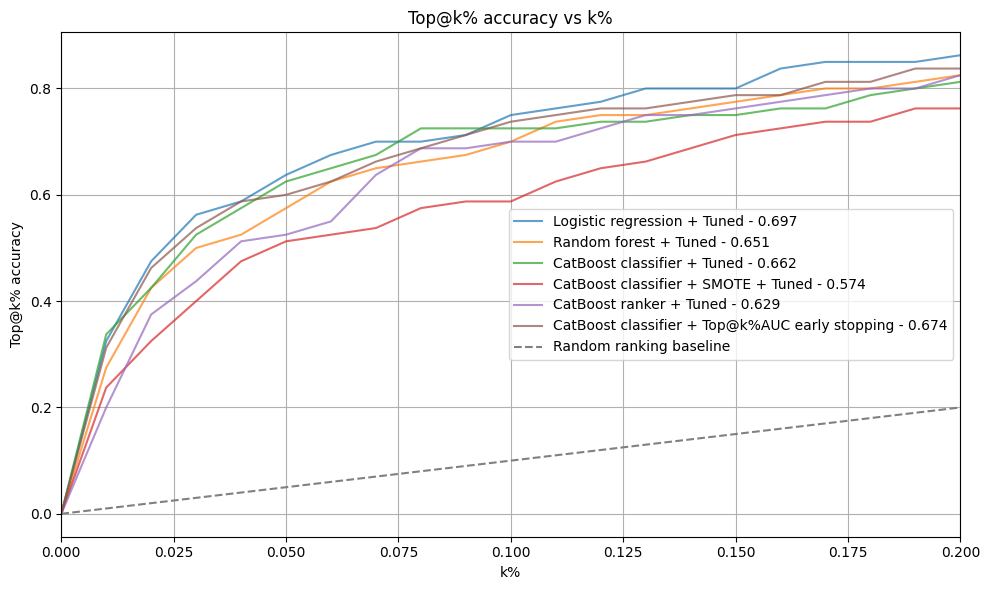

In [25]:
df_topkp_curves_test, auc_scores_test = evaluate_experiments_topk_percent_curves(
    experiments, dataset_type=DatasetType.TEST
)
plot_topk_percent_curves(
    df_topkp_curves_test,
    cols=cols,
    auc_scores=auc_scores_test,
    save_path="images/topkp_auc_test.png",
)
pd.Series(auc_scores_test, name="Top@k%AUC").sort_values(ascending=False)

Classification metrics (TEST):   0%|          | 0/11 [00:00<?, ?it/s]

Classification metrics (TEST):   9%|▉         | 1/11 [00:00<00:02,  4.89it/s]

Classification metrics (TEST):  18%|█▊        | 2/11 [00:00<00:01,  4.64it/s]

Classification metrics (TEST):  27%|██▋       | 3/11 [00:00<00:01,  4.31it/s]

Classification metrics (TEST):  36%|███▋      | 4/11 [00:00<00:01,  4.05it/s]

Classification metrics (TEST): 100%|██████████| 11/11 [00:01<00:00, 16.17it/s]

Classification metrics (TEST): 100%|██████████| 11/11 [00:01<00:00, 10.43it/s]

,PR-AUC,F1 (Top@1 per cross-section),Balanced Accuracy (Top@1 per cross-section)
Model,,,
Logistic regression,0.0511,0.1125,0.5547
Logistic regression + Tuned,0.0560,0.1000,0.5484
Random forest,0.0358,0.0750,0.5359
Random forest + Tuned,0.0592,0.1125,0.5547
CatBoost classifier,0.0662,0.1125,0.5547
CatBoost classifier + Tuned,0.0866,0.1375,0.5672
CatBoost classifier + SMOTE,0.0174,0.0625,0.5296
CatBoost classifier + SMOTE + Tuned,0.0575,0.1125,0.5547
CatBoost ranker,0.0333,0.1000,0.5484


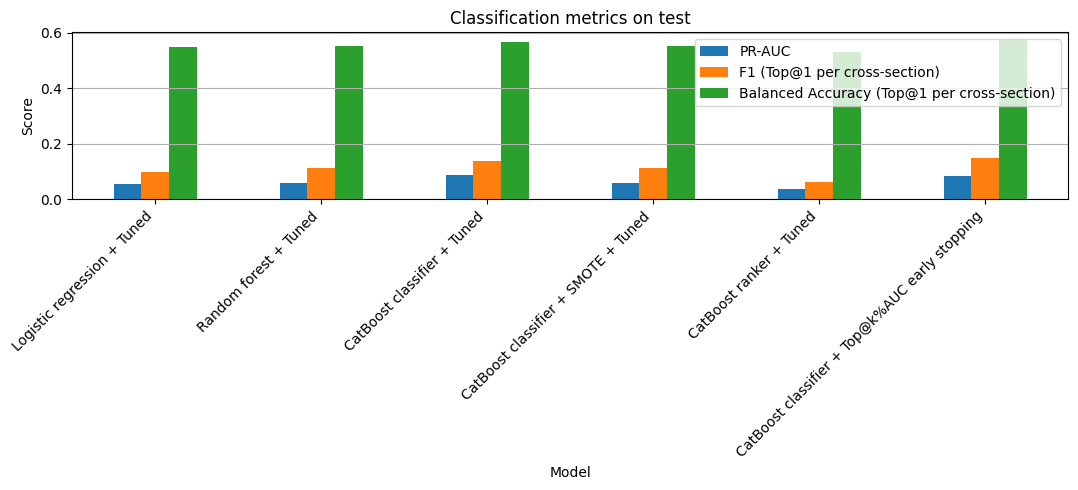

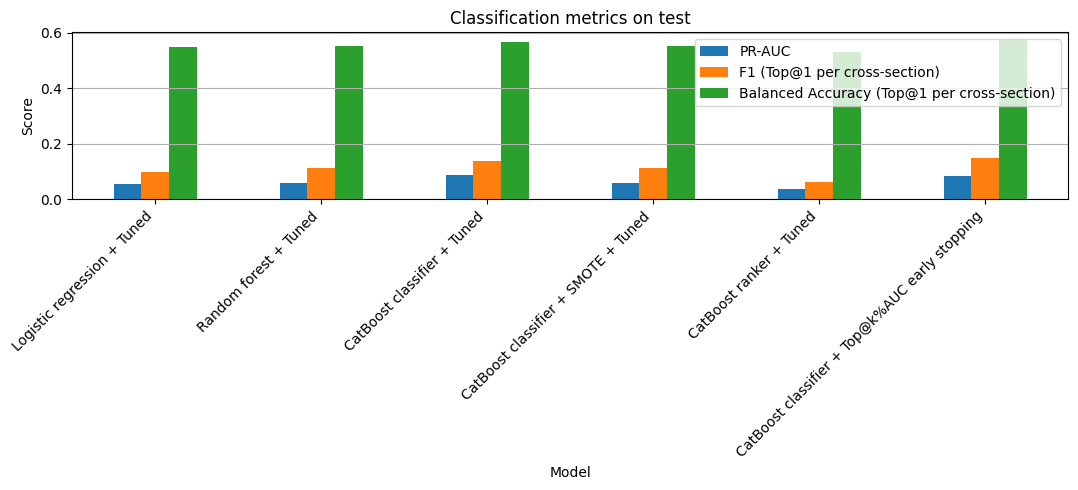

In [26]:
df_classification_test = evaluate_experiments_classification(experiments, dataset_type=DatasetType.TEST)
styled_test_classification = df_classification_test.style.apply(highlight_max, axis=0).format("{:.4f}")
display(styled_test_classification)
plot_classification_metrics(
    df_classification_test,
    cols=cols,
    title="Classification metrics on test",
    save_path="images/classification_metrics_test.png",
)

<h3>Test portfolio for the validation-selected model</h3>
<p>The portfolio backtest is run only for the model selected by validation Top@k%AUC. The primary portfolio size is fixed at k=5; other k values are descriptive sensitivity checks. BTC/USDT buy-and-hold is measured over the same test events.</p>

In [27]:
# Fixed before inspecting test portfolio outcomes.
PORTFOLIO_SIZE: int = 5
selected_curves: Dict[int, pd.Series] = {}
for k in [1, 2, 5, 10, 20, 30]:
    selected_curves[k] = get_equity_curve_for_experiment(
        experiment=selected_experiment, portfolio_size=k
    )

df = pd.concat(selected_curves, axis=1)
df.columns = [1, 2, 5, 10, 20, 30]
df_results = compute_portfolio_statistics(df)
test_dataset = selected_experiment.get_sample().get_dataset(ds_type=DatasetType.TEST)
btc_baseline = get_btc_buy_and_hold_baseline(test_dataset)
df_with_btc = df.copy()
df_with_btc["BTC B&H"] = btc_baseline["portfolio_return"]

df_stats_with_btc = compute_portfolio_statistics(df_with_btc)
print(f"Portfolio model selected on validation: {selected_experiment.get_experiment_name()}")
df_stats_with_btc

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=1:   0%|          | 0/80 [00:00<?, ?it/s]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=1:   1%|▏         | 1/80 [00:07<10:07,  7.69s/it]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=1:   5%|▌         | 4/80 [00:07<01:52,  1.48s/it]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=1:  10%|█         | 8/80 [00:07<00:43,  1.66it/s]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=1:  15%|█▌        | 12/80 [00:08<00:22,  2.96it/s]

...

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=30:  99%|█████████▉| 79/80 [01:14<00:00,  1.18it/s]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=30: 100%|██████████| 80/80 [01:15<00:00,  1.19it/s]

Equity curve: CatBoost classifier + Top@k%AUC early stopping K=30: 100%|██████████| 80/80 [01:15<00:00,  1.06it/s]

Portfolio model selected on validation: CatBoost classifier + Top@k%AUC early stopping


,average event return,annualized return,annualized volatility,Sharpe ratio
1,0.012293,0.762085,0.742274,1.026689
2,0.011837,0.733846,0.416050,1.763841
5,0.011962,0.741588,0.289595,2.560778
10,0.007189,0.445691,0.213046,2.091995
20,0.004314,0.267439,0.125148,2.136985
30,0.002948,0.182764,0.089378,2.044847
BTC B&H,-0.007168,-0.444358,0.454833,-0.976969


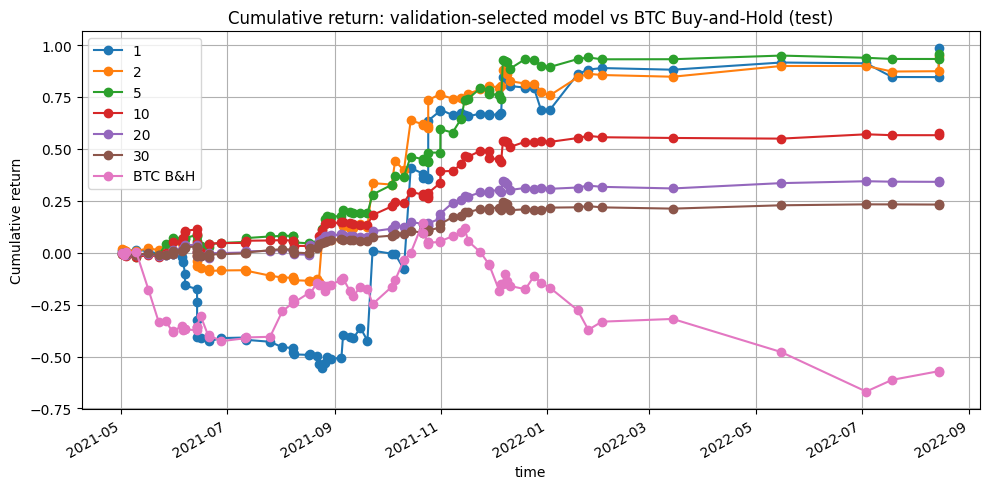

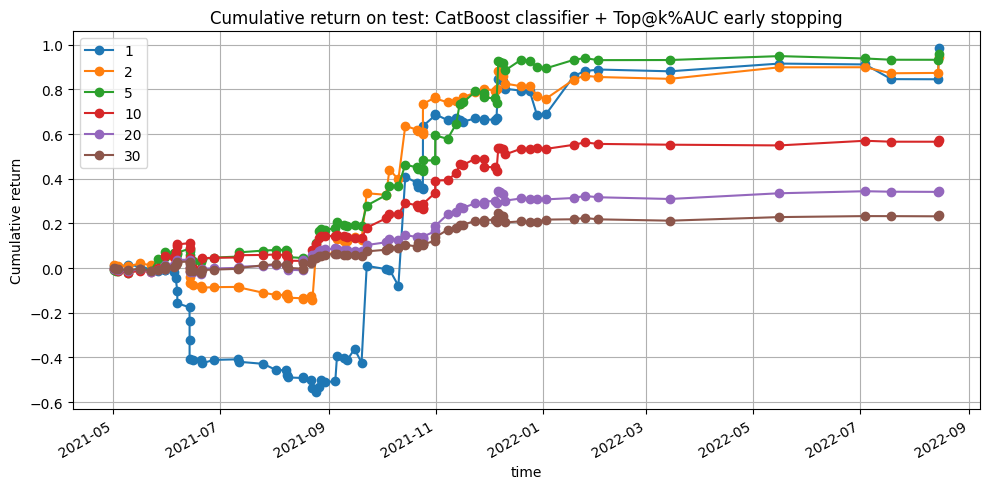

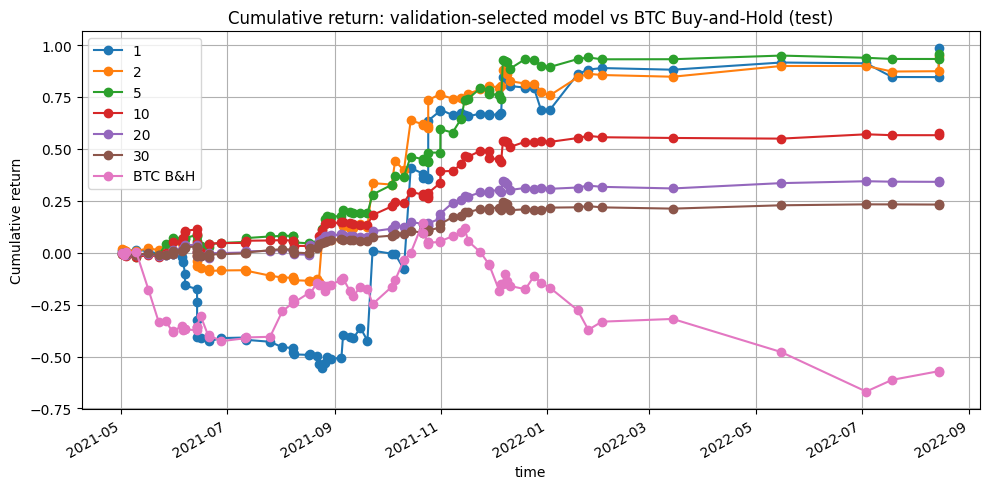

In [28]:
plot_equity_curves(
    df,
    title=f"Cumulative return on test: {selected_experiment.get_experiment_name()}",
    save_path="images/portfolios_test.png",
)
plot_equity_curves(
    df_with_btc,
    title="Cumulative return: validation-selected model vs BTC Buy-and-Hold (test)",
    save_path="images/portfolios_vs_btc_test.png",
)

<h4>Execution-aware PnL with price impact</h4>
<p>We fit a sqrt price-impact model I(Q) = β√Q (no intercept) for each traded asset using the previous 14 days of trade-level data resampled into 5-minute candles. Absolute net volume (|buy volume - sell volume|) and absolute price change (bps) from both buy and sell candles are pooled into a single regression. Each entry tracks the acquired base-asset inventory, the exit liquidates that full inventory, and both cash flows are converted to USDT at their respective completed indicative rates. Strategy PnL is then recomputed for different intended order sizes.</p>

In [29]:
from datetime import timedelta
from backtest.portfolio.TOPKPortfolio import evaluate_topk_pnl_for_quantities

impact_quantities_usdt = [100, 200, 500, 1000, 2000, 5000, 10000]

dataset_test = selected_experiment.get_sample().get_dataset(DatasetType.TEST)

df_pnl_by_quantity = evaluate_topk_pnl_for_quantities(
    model=selected_experiment.get_model(),
    dataset=dataset_test,
    portfolio_size=PORTFOLIO_SIZE,
    quantities_usdt=impact_quantities_usdt,
    buy_before=timedelta(minutes=15),
    sell_after=timedelta(minutes=1),
    impact_lookback_days=14,
)

df_pnl_by_quantity[["quantity_usdt", "cumulative_roe"]]

2026-08-16 14:36:03,340 | WARNING | root | Manipulated impact model has only 1 samples for APPC-BTC at pump=2021-08-08 01:00:00; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:36:03,770 | WARNING | root | Manipulated impact model has only 3 samples for APPC-BTC at pump=2021-12-19 15:00:04; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:36:06,657 | WARNING | root | Manipulated impact model has only 2 samples for CTXC-BTC at pump=2021-09-15 17:00:00; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:36:08,001 | WARNING | root | Manipulated impact model has only 6 samples for DLT-BTC at pump=2021-05-16 17:00:01; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:36:08,108 | WARNING | root | Manipulated impact model has only 1 samples for DLT-BTC at pump=2021-05-30 16:00:13; minimum is 20; falling back to pre-pump impact model for exit


...

2026-08-16 14:37:35,125 | WARNING | root | Manipulated impact model has only 6 samples for SKY-BTC at pump=2021-10-05 15:00:00; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:37:35,486 | WARNING | root | Manipulated impact model has only 0 samples for SNM-BTC at pump=2022-03-14 10:00:00; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:37:35,601 | WARNING | root | Manipulated impact model has only 4 samples for VIB-BTC at pump=2021-09-05 17:00:00; minimum is 20; falling back to pre-pump impact model for exit


2026-08-16 14:37:35,934 | WARNING | root | Manipulated impact model has only 1 samples for WABI-BTC at pump=2021-10-14 15:00:00; minimum is 20; falling back to pre-pump impact model for exit


,quantity_usdt,cumulative_roe
0,100.0,0.839940
1,200.0,0.791549
2,500.0,0.695668
3,1000.0,0.587826
4,2000.0,0.435697
5,5000.0,0.135173
6,10000.0,-0.201425


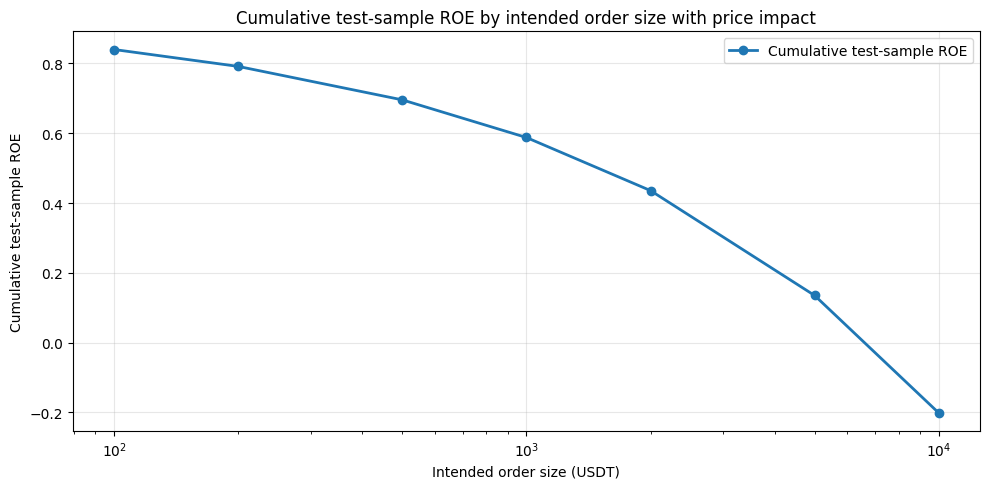

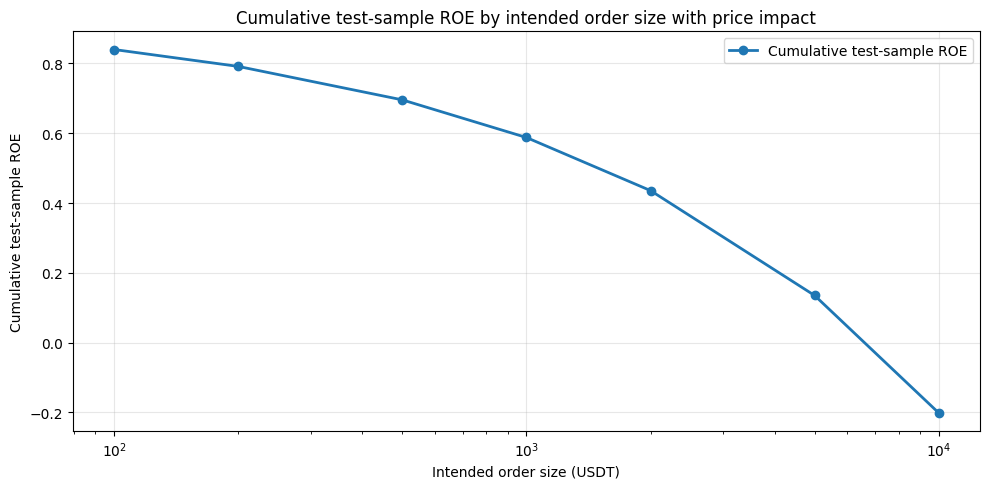

In [30]:
plot_pnl_sensitivity(df_pnl_by_quantity, save_path="images/pnl_vs_quantity_with_impact.png")

<h5>Entry impact: fitted sqrt model for one pump asset (5-min candles, 14-day lookback)</h5>
<p>Pick one pump asset with sufficient trade history. Resample trades into 5-minute candles, compute absolute net volume and absolute close-to-close price change, pool buy and sell candles, and fit I(Q) = β√Q via constrained OLS (β ≥ 0, no intercept). Fitting in USDT space ensures the impact curve is comparable across BTC price regimes.</p>
<pre>Q = |2 × taker_buy_volume − total_volume|  (absolute net volume per 5-min candle)</pre>
<pre>impact_bps = |close / prev_close − 1| × 10000  (absolute price change)</pre>

Buy side: n=1941, R²=0.3102, MAE=12.20 bps, RMSE=19.33 bps
Sell side: n=2034, R²=0.3548, MAE=13.01 bps, RMSE=20.45 bps
β = 0.722403


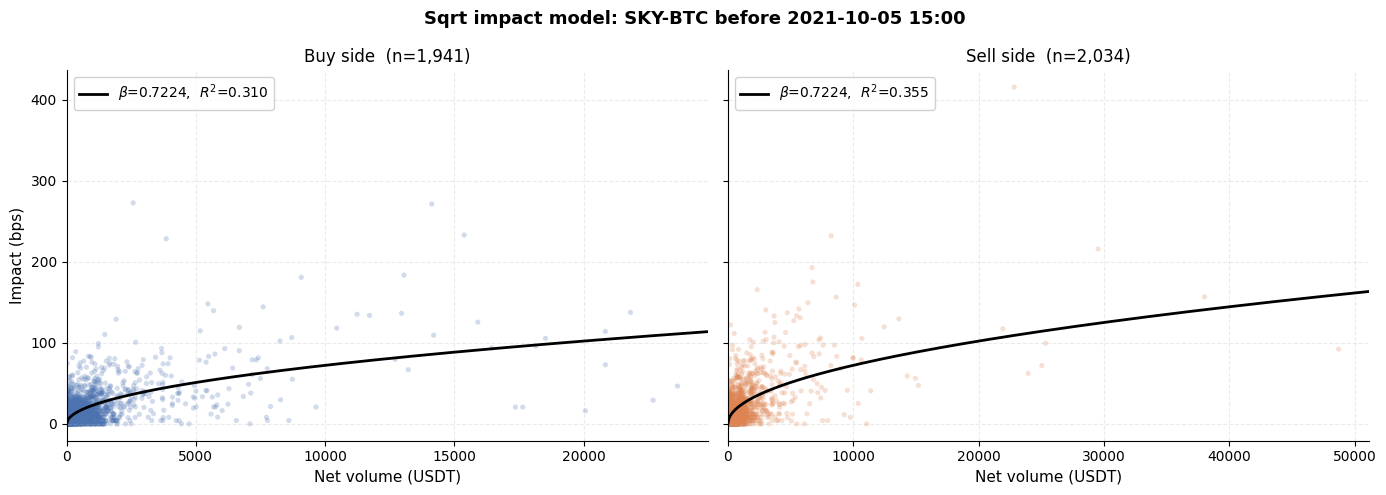

In [31]:
from backtest.utils.impact_example import find_best_impact_example

dataset_test = selected_experiment.get_sample().get_dataset(DatasetType.TEST)
example = find_best_impact_example(dataset_test)

samples = example.fit_result.samples[example.fit_result.samples["notional_usdt"] > 0].copy()
plot_impact_regression(
    model=example.fit_result.model,
    samples=samples,
    currency_pair_name=example.currency_pair.name,
    pump_time=example.pump.time,
    save_path="images/impact_regression_example.png",
)

# Regression quality metrics
for side_label, side_val in [("Buy", 1), ("Sell", -1)]:
    import numpy as np
    side_df = samples[samples["side"] == side_val]
    if len(side_df) == 0:
        continue
    y_obs = side_df["impact_bps"].values
    y_pred = example.fit_result.model.beta * np.sqrt(side_df["notional_usdt"].values)
    ss_res = np.sum((y_obs - y_pred) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    mae = np.mean(np.abs(y_obs - y_pred))
    rmse = np.sqrt(np.mean((y_obs - y_pred) ** 2))
    
    print(f"{side_label} side: n={len(side_df)}, R²={r2:.4f}, MAE={mae:.2f} bps, RMSE={rmse:.2f} bps")
    
print(f"β = {example.fit_result.model.beta:.6f}")

<h5>Exit impact: fitted sqrt model for manipulated asset (5-sec candles, sell-only)</h5>
<p>For the pumped asset, the execution backtest estimates exit impact from the causal window beginning at the announcement and ending strictly before the realised exit timestamp (capped at 10 minutes). The illustrative figure below uses the full 10-minute event window to show the manipulation regime; it is not the model used for a one-minute exit. Trades are resampled into 5-second candles and only sell-dominated candles (negative net buying volume) are used.</p>
<pre>Q = |net sell volume| per 5-sec candle (sell-dominated candles only)</pre>
<pre>impact_bps = |close / prev_close − 1| × 10000</pre>

Exit impact (sell-only, 5s candles):
  n=83, R²=0.2736, MAE=44.31 bps, RMSE=82.61 bps
  β = 1.318804
  Asset: DLT-BTC, Pump: 2021-06-13 17:01:00


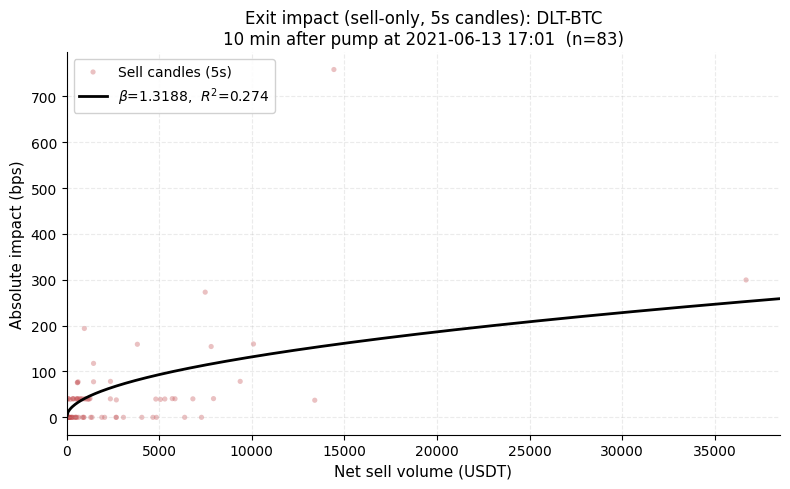

In [32]:
from backtest.utils.impact_example import find_best_exit_impact_example
from backtest.utils.graphs import plot_exit_impact_regression

exit_example = find_best_exit_impact_example(dataset_test)

exit_samples = exit_example.fit_result.samples.copy()
plot_exit_impact_regression(
    model=exit_example.fit_result.model,
    samples=exit_samples,
    currency_pair_name=exit_example.currency_pair.name,
    pump_time=exit_example.pump.time,
    save_path="images/exit_impact_regression_example.png",
)

# Regression quality metrics for exit
y_obs = exit_samples["impact_bps"].values
y_pred = exit_example.fit_result.model.beta * np.sqrt(exit_samples["notional_usdt"].values)
ss_res = np.sum((y_obs - y_pred) ** 2)
ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
mae = np.mean(np.abs(y_obs - y_pred))
rmse = np.sqrt(np.mean((y_obs - y_pred) ** 2))
print(f"Exit impact (sell-only, 5s candles):")
print(f"  n={len(exit_samples)}, R²={r2:.4f}, MAE={mae:.2f} bps, RMSE={rmse:.2f} bps")
print(f"  β = {exit_example.fit_result.model.beta:.6f}")
print(f"  Asset: {exit_example.currency_pair.name}, Pump: {exit_example.pump.time}")

<h4>Robustness checks: train on subset of cross-sections</h4>
<p>We repeatedly train the same pipeline on random subsets of <code>TRAIN</code> cross-sections, evaluate on the fixed <code>TEST</code> split, and collect a distribution of ranking metrics.</p>

In [33]:
from pathlib import Path
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline
from backtest.robust.robustness import (
    run_cross_section_subset_robustness,
    summarise_robustness_distribution,
    summarise_feature_importance_distribution,
)

ROBUSTNESS_OUTPUT: Path = Path("analysis_outputs/robustness/catboost_topkauc_subset_runs.csv")
FEATURE_IMPORTANCE_OUTPUT: Path = Path("analysis_outputs/robustness/catboost_topkauc_feature_importances.csv")

# The same resample-train-fit loop that produces the Top@k%AUC distribution now also
# records the model's feature importances on every run, giving a training-subset distribution
# of feature importances for Catboost + ES.
df_robustness: pd.DataFrame = run_cross_section_subset_robustness(
    pipeline_factory=CatboostClassifierTOPKAUCPipeline,
    subset_fraction=0.7,
    n_runs=25,
    tuned=True,
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
    base_seed=42,
    output_path=ROBUSTNESS_OUTPUT,
    collect_feature_importances=True,
    feature_importance_output_path=FEATURE_IMPORTANCE_OUTPUT,
)

df_robustness.head()

2026-08-16 14:37:57,408 | INFO | root | Using cached preprocessed datasets for CatboostClassifierTOPKAUCPipeline


0:	learn: 0.3517241	test: 0.4768204	best: 0.4768204 (0)	total: 21.5ms	remaining: 21.4s
10:	learn: 0.5072044	test: 0.5720874	best: 0.5930825 (3)	total: 51.5ms	remaining: 4.63s
20:	learn: 0.5461823	test: 0.6115291	best: 0.6115291 (20)	total: 83.3ms	remaining: 3.88s


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Can't optimze method "evaluate" because self argument is used
  _check_train_params(params)


30:	learn: 0.5702586	test: 0.6178398	best: 0.6178398 (30)	total: 116ms	remaining: 3.61s
40:	learn: 0.5914409	test: 0.6231796	best: 0.6279126 (38)	total: 148ms	remaining: 3.46s
50:	learn: 0.6019089	test: 0.6297330	best: 0.6297330 (50)	total: 179ms	remaining: 3.34s
60:	learn: 0.6167488	test: 0.6309466	best: 0.6337379 (55)	total: 212ms	remaining: 3.26s


70:	learn: 0.6274015	test: 0.6382282	best: 0.6387136 (68)	total: 244ms	remaining: 3.19s
80:	learn: 0.6318350	test: 0.6342233	best: 0.6387136 (68)	total: 278ms	remaining: 3.15s
90:	learn: 0.6449507	test: 0.6359223	best: 0.6387136 (68)	total: 310ms	remaining: 3.1s


...

0:	learn: 0.3522167	test: 0.4751214	best: 0.4751214 (0)	total: 19.7ms	remaining: 19.7s
10:	learn: 0.5049877	test: 0.6157767	best: 0.6157767 (10)	total: 50.9ms	remaining: 4.58s
20:	learn: 0.5418719	test: 0.6168689	best: 0.6262136 (15)	total: 83.2ms	remaining: 3.88s
30:	learn: 0.5740764	test: 0.6283981	best: 0.6287621 (29)	total: 115ms	remaining: 3.59s
40:	learn: 0.5974138	test: 0.6412621	best: 0.6421117 (39)	total: 147ms	remaining: 3.44s
50:	learn: 0.6206281	test: 0.6434466	best: 0.6447816 (43)	total: 180ms	remaining: 3.34s
60:	learn: 0.6386700	test: 0.6384709	best: 0.6447816 (43)	total: 212ms	remaining: 3.27s


70:	learn: 0.6421798	test: 0.6349515	best: 0.6447816 (43)	total: 244ms	remaining: 3.19s
80:	learn: 0.6489532	test: 0.6270631	best: 0.6447816 (43)	total: 277ms	remaining: 3.14s
90:	learn: 0.6657635	test: 0.6262136	best: 0.6447816 (43)	total: 309ms	remaining: 3.08s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6447815534
bestIteration = 43

Shrink model to first 44 iterations.


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Can't optimze method "evaluate" because self argument is used
  _check_train_params(params)


0:	learn: 0.3612685	test: 0.4820388	best: 0.4820388 (0)	total: 20.6ms	remaining: 20.6s
10:	learn: 0.5261084	test: 0.5986650	best: 0.6163835 (7)	total: 51.5ms	remaining: 4.63s
20:	learn: 0.5628079	test: 0.5945388	best: 0.6163835 (7)	total: 84.1ms	remaining: 3.92s
30:	learn: 0.5910099	test: 0.5936893	best: 0.6163835 (7)	total: 116ms	remaining: 3.63s
40:	learn: 0.6118842	test: 0.6097087	best: 0.6163835 (7)	total: 148ms	remaining: 3.47s
50:	learn: 0.6198892	test: 0.6154126	best: 0.6163835 (7)	total: 181ms	remaining: 3.37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6163834951
bestIteration = 7

Shrink model to first 8 iterations.


,run_idx,seed,subset_fraction,train_rows,train_cross_sections,test_rows,test_cross_sections,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,0,42,0.7,31347,203,23015,80,0.695625,0.3625,0.5000,0.6500,0.7500,0.8500
1,1,43,0.7,31647,203,23015,80,0.679844,0.3625,0.5125,0.6250,0.7250,0.8375
2,2,44,0.7,31550,203,23015,80,0.687813,0.3000,0.4000,0.6500,0.7375,0.8500
3,3,45,0.7,31472,203,23015,80,0.689688,0.3250,0.4625,0.6375,0.7375,0.8500
4,4,46,0.7,31424,203,23015,80,0.670625,0.3125,0.4875,0.6000,0.7125,0.8250


In [34]:
robustness_summary: pd.DataFrame = summarise_robustness_distribution(
    results=df_robustness,
    metric_cols=[
        "topk_percent_auc",
        "topk_percent@0.01",
        "topk_percent@0.02",
        "topk_percent@0.05",
        "topk_percent@0.1",
        "topk_percent@0.2",
    ],
)

robustness_summary

,count,mean,std,min,10%,25%,50%,75%,90%,max
topk_percent_auc,25.0,0.677656,0.012807,0.6450,0.661719,0.670625,0.679688,0.687656,0.692719,0.695625
topk_percent@0.01,25.0,0.334000,0.038277,0.2000,0.305000,0.312500,0.337500,0.362500,0.370000,0.400000
topk_percent@0.02,25.0,0.462500,0.032275,0.3625,0.437500,0.450000,0.462500,0.475000,0.500000,0.512500
topk_percent@0.05,25.0,0.619000,0.022569,0.5625,0.592500,0.612500,0.612500,0.637500,0.645000,0.662500
topk_percent@0.1,25.0,0.727000,0.016008,0.7000,0.705000,0.712500,0.725000,0.737500,0.745000,0.762500
topk_percent@0.2,25.0,0.838500,0.016504,0.7875,0.825000,0.825000,0.837500,0.850000,0.857500,0.862500


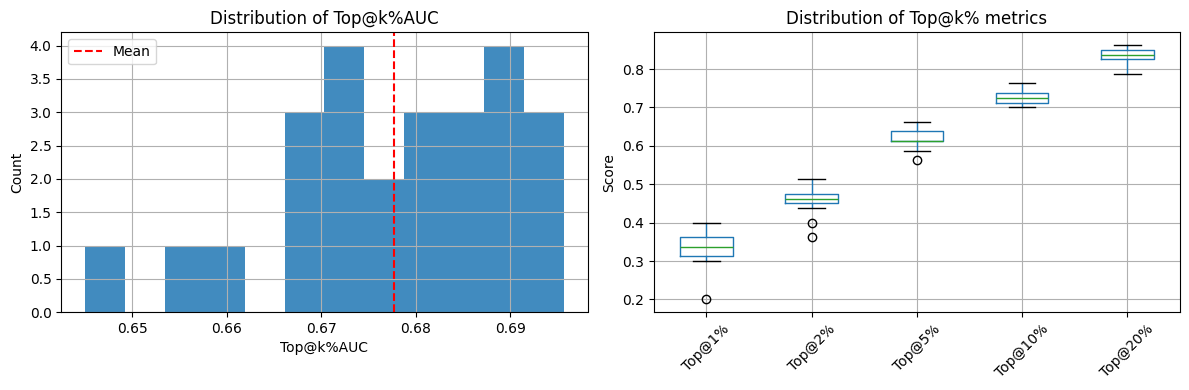

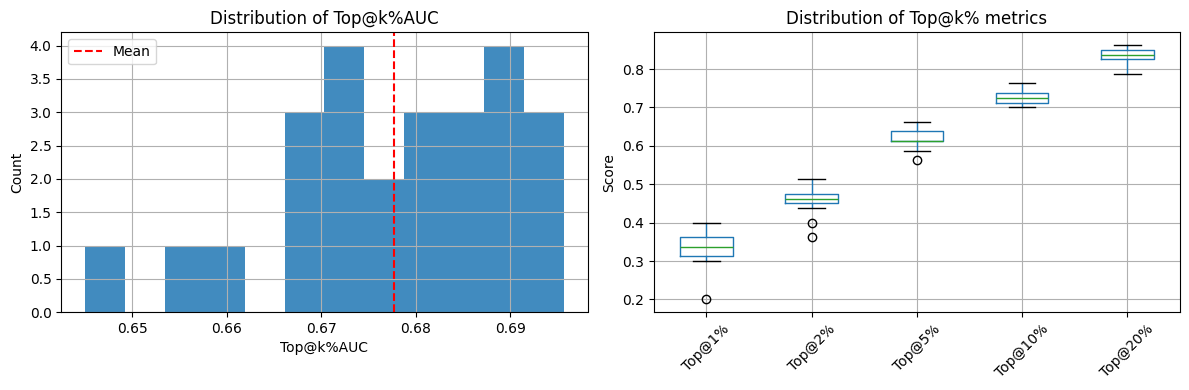

In [35]:
metric_cols = ["topk_percent@0.01", "topk_percent@0.02", "topk_percent@0.05", "topk_percent@0.1", "topk_percent@0.2"]
plot_robustness_distribution(df_robustness, metric_cols=metric_cols,
                             save_path="images/robustness_metrics_distribution.png")

<h4>Training-subset feature importances</h4>
<p>The same retraining runs that produced the Top@k%AUC distribution above also recorded the model's feature importances (PredictionValuesChange) on every fit. This yields a training-subset distribution of importance per feature. We summarise it as per-feature quantiles sorted by median, visualise the spread of the most important features, and export the quantile table to the paper.</p>

In [36]:
df_feature_importances: pd.DataFrame = df_robustness.attrs["feature_importances"]

fi_summary: pd.DataFrame = summarise_feature_importance_distribution(
    df_feature_importances,
    quantiles=(0.1, 0.25, 0.5, 0.75, 0.9),
    top_n=15,
)
fi_summary

,mean,std,p10,p25,p50,p75,p90
feature,,,,,,,
num_prev_pump,17.019596,6.976776,8.741850,12.584454,16.281566,20.574433,25.878471
num_trades@14D,7.125103,4.823412,2.691256,4.030312,7.114614,8.677577,13.038221
num_trades@7D,6.843047,3.939769,2.553200,3.715892,5.923102,8.667938,10.913035
num_trades@2D,6.796035,6.097284,0.502090,2.172092,5.016478,8.567554,16.597008
asset_return@4H,3.307807,3.522395,0.450267,1.842726,2.683933,4.118413,4.815717
slippage_imbalance@12H,3.593011,3.620154,0.000000,0.826390,2.601850,4.871967,8.759103
slippage_imbalance@2D,3.101579,2.820879,0.435291,1.121719,2.345233,3.834309,7.515069
asset_return@2H,2.818812,1.749677,0.664173,1.803808,2.247866,4.075347,5.366663
quote_abs_zscore@1H,2.269181,1.715705,0.255750,1.135272,2.241663,2.949649,4.485613


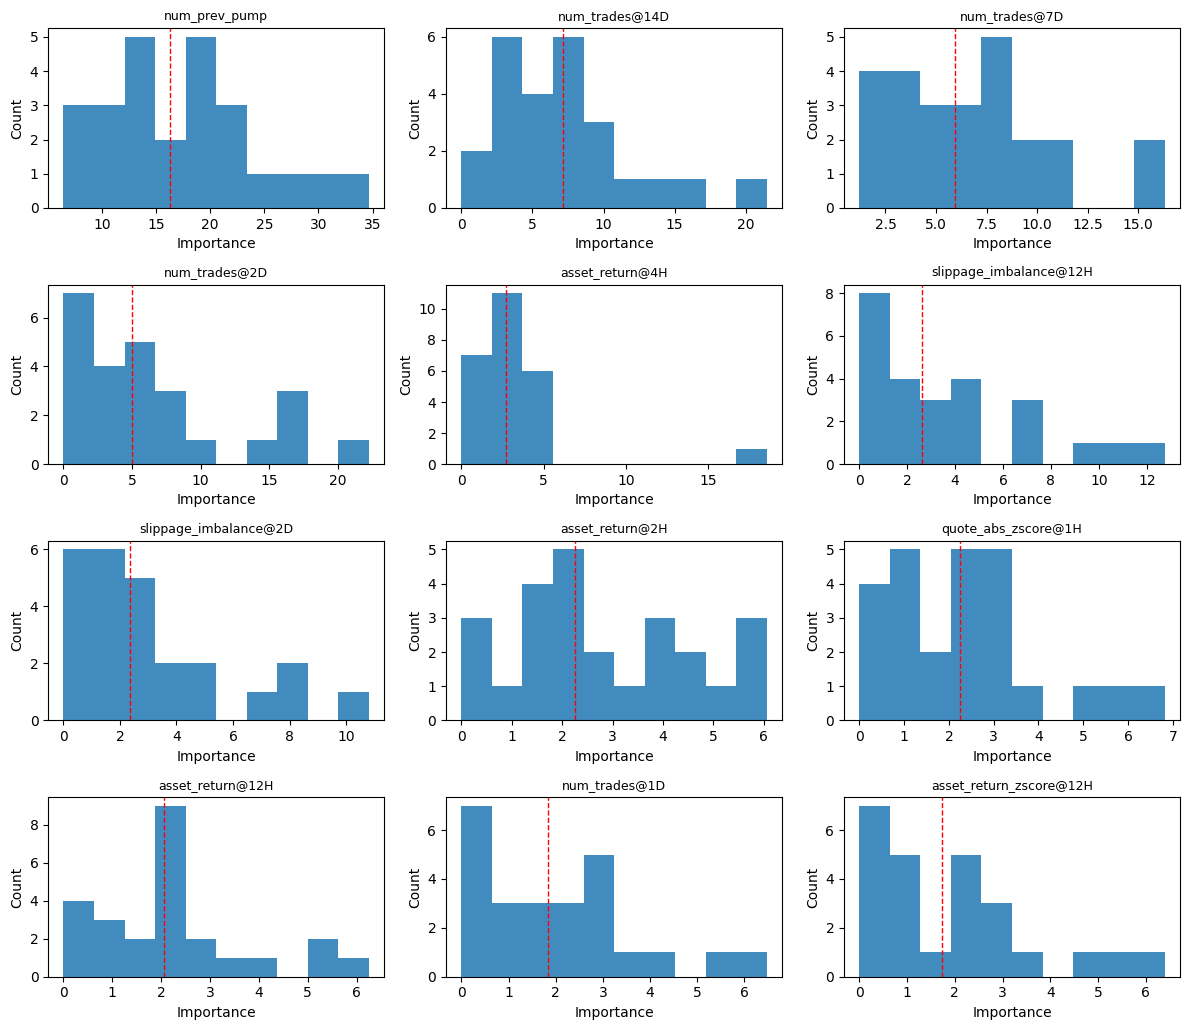

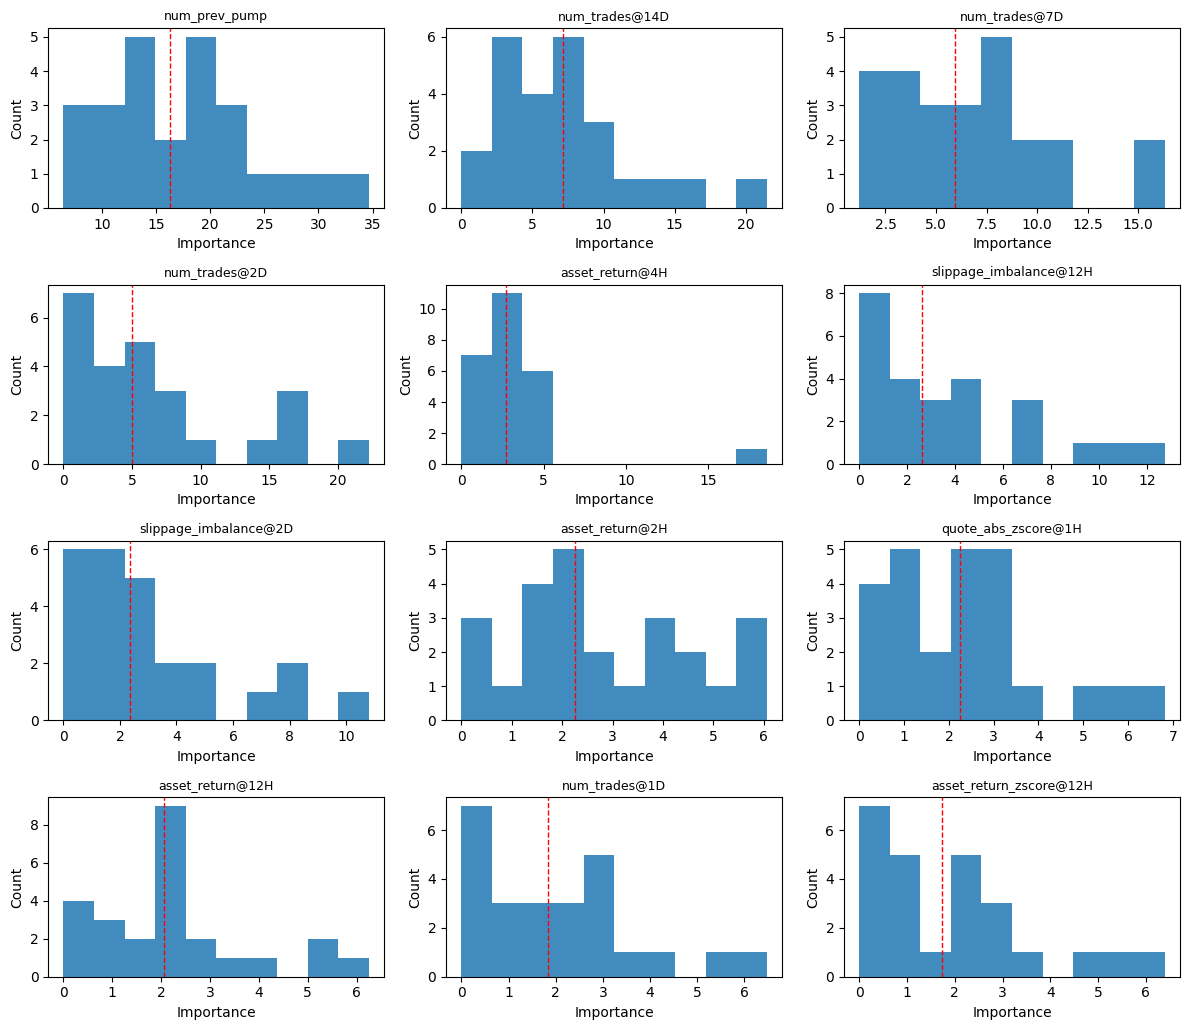

In [37]:
plot_feature_importance_distribution(
    df_feature_importances,
    top_n=12,
    n_cols=3,
    save_path="images/feature_importance_distribution.png",
)

In [38]:
# Export the feature-importance quantile table (sorted by median) consumed by the paper.
TABLE_TOP_N: int = 15
fi_table: pd.DataFrame = summarise_feature_importance_distribution(
    df_feature_importances,
    quantiles=(0.1, 0.25, 0.5, 0.75, 0.9),
    top_n=TABLE_TOP_N,
)

paper_table = (
    fi_table[["p10", "p25", "p50", "p75", "p90"]]
    .rename(columns={"p10": "10%", "p25": "25%", "p50": "Median", "p75": "75%", "p90": "90%"})
    .rename_axis("Feature")
)
fi_table

,mean,std,p10,p25,p50,p75,p90
feature,,,,,,,
num_prev_pump,17.019596,6.976776,8.741850,12.584454,16.281566,20.574433,25.878471
num_trades@14D,7.125103,4.823412,2.691256,4.030312,7.114614,8.677577,13.038221
num_trades@7D,6.843047,3.939769,2.553200,3.715892,5.923102,8.667938,10.913035
num_trades@2D,6.796035,6.097284,0.502090,2.172092,5.016478,8.567554,16.597008
asset_return@4H,3.307807,3.522395,0.450267,1.842726,2.683933,4.118413,4.815717
slippage_imbalance@12H,3.593011,3.620154,0.000000,0.826390,2.601850,4.871967,8.759103
slippage_imbalance@2D,3.101579,2.820879,0.435291,1.121719,2.345233,3.834309,7.515069
asset_return@2H,2.818812,1.749677,0.664173,1.803808,2.247866,4.075347,5.366663
quote_abs_zscore@1H,2.269181,1.715705,0.255750,1.135272,2.241663,2.949649,4.485613


<h4>Temporal robustness: subperiod analysis</h4>
<p>We split the test set at a pre-specified regime date and evaluate Top@k% and Top@k%AUC in each subperiod that passes the minimum-event guard. This checks whether the model generalises across market regimes without reporting unstable tiny-sample estimates.</p>

In [39]:
from backtest.robust.robustness import evaluate_subperiod_metrics

best_model = selected_experiment.get_model()
test_df = selected_experiment.get_sample().get_dataset(DatasetType.TEST).all_data()

df_subperiod = evaluate_subperiod_metrics(
    model=best_model,
    dataset_df=test_df,
    date_col="pump_time",
    split_date="2022-06-01",
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
)

df_subperiod

2026-08-16 14:38:15,469 | WARNING | root | Skipping 'late' subperiod: only 4 pump(s), below min_pumps=10. Metrics on tiny subperiods are unstable.


,subperiod,n_pumps,n_rows,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,early,76,21814,0.675822,0.328947,0.486842,0.605263,0.736842,0.828947


<h4>Statistical significance: bootstrap CIs and paired hypothesis test</h4>
<p>Below we quantify uncertainty (95% confidence intervals) and test whether performance differences are statistically meaningful.</p>

In [40]:
from backtest.robust.significance import (
    score_dataset,
    bootstrap_topk_ci,
    bootstrap_topk_percent_ci,
    bootstrap_topk_percent_auc_ci,
    paired_bootstrap_topk_percent_auc_test,
)

# ES vs the strongest non-ES baseline selected on VALIDATION Top@k%AUC.
# TEST is touched only after the comparator has been fixed.
exp_a = experiment_cb_topkpauc_tuned
_baseline_map = {
    "Logistic regression": experiment_lr,
    "Logistic regression + Tuned": experiment_lr_tuned,
    "Random forest": experiment_rf,
    "Random forest + Tuned": experiment_rf_tuned,
    "CatBoost classifier": experiment_cb,
    "CatBoost classifier + Tuned": experiment_cb_tuned,
    "CatBoost classifier + SMOTE": experiment_cb_smote,
    "CatBoost classifier + SMOTE + Tuned": experiment_cb_smote_tuned,
    "CatBoost ranker": experiment_cb_ranker,
    "CatBoost ranker + Tuned": experiment_cb_ranker_tuned,
}
from backtest.utils.metrics import calculate_topk_percent_auc
_validation_scores = {
    name: calculate_topk_percent_auc(
        model=experiment.get_model(),
        dataset=experiment.get_sample().get_dataset(DatasetType.VALIDATION),
    )
    for name, experiment in _baseline_map.items()
}
_baseline_name = max(_validation_scores, key=_validation_scores.get)
exp_b = _baseline_map[_baseline_name]
print(f"Paired test baseline selected on validation: {exp_b.get_experiment_name()} "
      f"(validation Top@k%AUC {_validation_scores[_baseline_name]:.4f})")

scored_a = score_dataset(
    model=exp_a.get_model(),
    dataset=exp_a.get_sample().get_dataset(DatasetType.TEST),
)
scored_b = score_dataset(
    model=exp_b.get_model(),
    dataset=exp_b.get_sample().get_dataset(DatasetType.TEST),
)

ci_auc_a = bootstrap_topk_percent_auc_ci(scored_df=scored_a, n_bootstrap=1000, alpha=0.05, random_state=42)
ci_auc_b = bootstrap_topk_percent_auc_ci(scored_df=scored_b, n_bootstrap=1000, alpha=0.05, random_state=42)

df_auc_ci = pd.DataFrame([
    {"model": exp_a.get_experiment_name(), **ci_auc_a.to_dict()},
    {"model": exp_b.get_experiment_name(), **ci_auc_b.to_dict()},
]).set_index("model")

df_auc_ci[["point_estimate", "ci_lower", "ci_upper"]]


Paired test baseline selected on validation: CatBoost classifier + Tuned (validation Top@k%AUC 0.6552)


,point_estimate,ci_lower,ci_upper
model,,,
CatBoost classifier + Top@k%AUC early stopping,0.673906,0.592176,0.754699
CatBoost classifier + Tuned,0.662344,0.575129,0.746723


In [41]:
topk_bins = [1, 2, 3, 5, 10, 20, 30]
topkp_bins = [0.01, 0.02, 0.05, 0.1, 0.2]

df_topk_ci = bootstrap_topk_ci(
    scored_df=scored_a,
    bins=topk_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topkp_ci = bootstrap_topk_percent_ci(
    scored_df=scored_a,
    bins=topkp_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topk_ci

,point_estimate,mean_bootstrap,std_bootstrap,ci_lower,ci_upper,n_bootstrap,alpha
1,0.1500,0.151312,0.040633,0.0750,0.2250,1000,0.05
2,0.2250,0.227975,0.047536,0.1500,0.3250,1000,0.05
3,0.3125,0.314775,0.052830,0.2125,0.4250,1000,0.05
5,0.3875,0.387675,0.055004,0.2875,0.4875,1000,0.05
10,0.5625,0.561987,0.056885,0.4625,0.6750,1000,0.05
20,0.6625,0.661850,0.053056,0.5625,0.7625,1000,0.05
30,0.7500,0.750313,0.048839,0.6500,0.8375,1000,0.05


In [42]:
paired_test = paired_bootstrap_topk_percent_auc_test(
    scored_df_a=scored_a,
    scored_df_b=scored_b,
    n_bootstrap=2000,
    alpha=0.05,
    random_state=42,
    alternative="greater",
)

pd.Series(paired_test.to_dict())

metric                 topk_percent_auc
observed_diff                  0.011563
mean_diff_bootstrap            0.011499
ci_lower                      -0.012031
ci_upper                       0.036875
p_value                        0.173913
alternative                     greater
n_bootstrap                        2000
alpha                              0.05
dtype: object

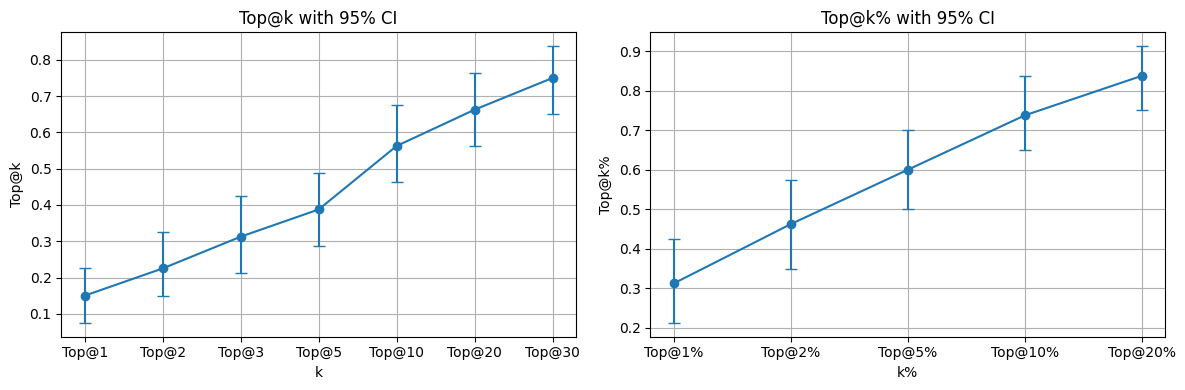

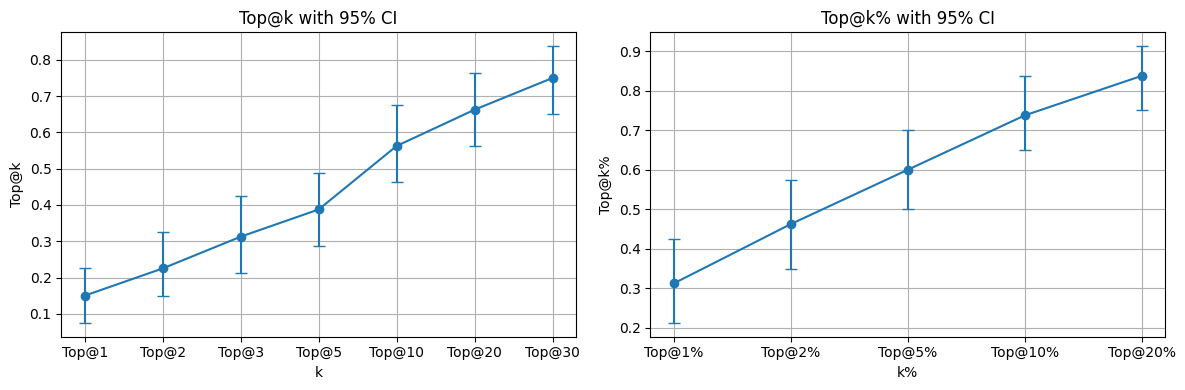

In [43]:
plot_bootstrap_ci(df_topk_ci, df_topkp_ci, save_path="images/significance_bootstrap_ci.png")

<!-- Superseded audit retained in notebook source for provenance.
<h4>Code audit: bugs and mistakes (2026-07-04)</h4>

<p>Read-only correctness pass over <code>features/</code>, <code>backtest/pipelines/</code>, <code>backtest/portfolio/</code>, <code>backtest/utils/</code>, <code>backtest/robust/</code>, plus a data-pipeline sweep over <code>core/</code>, <code>market_data/</code>, <code>preprocessing/</code>. Every file read end-to-end; suspected defects verified by tracing the call path or a scratchpad repro. No code changed.</p>

<p><b>Test / lint status:</b> <code>poetry run pytest -q</code> 32/32 passing. <code>just mypy</code> 94 errors (predominantly missing third-party stubs; a handful of real ones flagged below). <code>just pylint</code> 8.15 / 10, dominated by duplicate-code across the pipeline wrappers.</p>
-->


<!-- Superseded by the 2026-08-12 audit below.
<h4>Critical &mdash; affects reported results</h4>

<p><b>1. Portfolio hyperparameters tuned directly on TEST.</b> <code>BasePipeline.optimize_portfolio_strategy</code> (BasePipeline.py:171) runs Optuna against <code>portfolio_pnl_objective</code>, which evaluates on <code>DatasetType.TEST</code> (TOPKPortfolio.py:373). <code>buy_before</code>, <code>sell_after</code>, and <code>portfolio_size</code> are therefore selected in-sample on the test set; any reported test PnL from a tuned config is upward-biased.</p>

<p><b>2. Exit-impact model fitted on post-exit data.</b> <code>ManipulatedImpactModelProvider.get_impact_model</code> (manipulated_impact_provider.py:54, 63-66) accepts an <code>end_exclusive</code> argument but ignores it and always fits on <code>[pump.time, pump.time + 10min)</code>. The caller (TOPKPortfolio.py:172-176) passes <code>end_exclusive=intent.exit_ts</code>, i.e. it wants the exit-impact fit restricted to pre-exit data. With <code>sell_after=1min</code>, roughly nine minutes of strictly post-exit candles leak into the exit &beta;, and the cache key does not include <code>end_exclusive</code> so a later fix would silently return a stale model.</p>

<p><b>3. Z-score feature scalers include the pump hour.</b> <code>PumpsFeatureWriter.compute_features</code> (FeatureWriter.py:135-146) computes <code>asset_return_std</code>, <code>quote_abs_mean</code>, <code>quote_abs_std</code> on hourly bars derived from <code>df</code>, whose bounds run through <code>pump.time + 1h</code>. Those stats are then used inside <code>compute_asset_return_zscore</code> / <code>compute_quote_abs_zscore</code> to normalise the pre-pump z-score features (FeatureWriter.py:165-168). Every <code>asset_return_zscore@*</code> and <code>quote_abs_zscore@*</code> value is scaled by a divisor that peeked into the label horizon; the leak is largest on the pumped asset.</p>

<p><b>4. Survivorship filter uses the post-pump label before the time split.</b> <code>remove_failed_pump_cross_sections</code> (BasePipeline.py:76-97) runs inside <code>preprocess_data</code>, i.e. before <code>split_by_time</code> (BasePipeline.py:141). It ranks cross-sections by <code>target_return@1MIN</code> and drops any pump where the pumped asset did not reach top-10 by 1-minute post-pump return. Applied uniformly to train, validation, and test. All reported Top@k, Top@k%AUC, PnL, and Sharpe on TEST are conditioned on the pump actually being successful within one minute.</p>

<p><b>5. HIVE preprocessing re-run duplicates partitions.</b> <code>preprocessing/binance_spot_trades_to_hive.py:60-67</code> writes the parquet dataset with <code>existing_data_behavior="overwrite_or_ignore"</code> plus a UUID-based basename. Because <code>overwrite_or_ignore</code> only overwrites files with the same name (which the UUID prevents), re-running the ingestion on the same day/symbol adds a fresh set of files alongside the existing ones. A synthetic repro on the scratchpad confirmed all rows in the affected <code>(date, symbol)</code> partitions are duplicated per re-run, which silently inflates every downstream volume, flow-imbalance, and impact number.</p>
-->


<!-- Superseded by the 2026-08-12 audit below.
<h4>Major</h4>

<p><b>Feature/label leakage and boundary bugs.</b></p>
<ul>
<li><code>features/FeatureWriter.py:87</code> &mdash; <code>load_data_for_currency_pair</code> uses <code>pl.col(TRADE_TIME).is_between(bounds.start_inclusive, bounds.end_exclusive)</code> with the polars default <code>closed="both"</code>, so <code>bounds.end_exclusive</code> is included despite the name. Off-by-one against every other loader in the tree.</li>
<li><code>backtest/pipelines/BasePipeline.py:100-110</code> &mdash; <code>fillna_with_median_by_cross_section</code> computes <code>global_medians</code> on the full pre-split df (train + val + test) and uses them as fallback for any NaN left after the per-cross-section median fill. Test-distribution medians leak into training features.</li>
<li><code>core/time_utils.py:96-113</code> &mdash; <code>Bounds.for_days</code> sets <code>end_exclusive = day1.midnight + 1day - 1&mu;s</code>, so the "exclusive" end is actually inclusive of the last day at 23:59:59.999999. <code>contains_days</code> / <code>date_range</code> / <code>generate_year_month_strings</code> (lines 158-201) treat <code>end_exclusive.date()</code> as inclusive, which is off-by-one for a bound that really is exclusive. <code>Bounds.for_days(d, d)</code> produces an inverted range (<code>start &gt; end</code>) which the polars filter treats as empty rather than raising.</li>
<li><code>core/time_utils.py:32-52</code> &mdash; <code>generate_daily_time_chunks</code> drops an entire month whenever an endpoint falls on the 1st (e.g. Jan 1 &rarr; Feb 1 yields <code>[]</code>). Currently unused, but exported.</li>
</ul>

<p><b>Portfolio / execution.</b></p>
<ul>
<li><code>backtest/portfolio/TOPKPortfolio.py:262-327</code> &mdash; <code>evaluate_pnl_for_quantities</code> mutates <code>self.config.use_price_impact</code>, <code>order_notional_quote</code>, <code>order_notional_usdt</code> inside a try/finally. Not thread-safe; any concurrent <code>evaluate_for_pump</code> on the same instance sees transient state.</li>
<li><code>backtest/portfolio/TOPKPortfolio.py:196-197</code> &mdash; <code>entry_filled_notional_quote</code> and <code>exit_filled_notional_quote</code> are both set to <code>execution.filled_notional_quote</code>. Numerically fine today because <code>USDTPnLCalculator</code> treats the value as the invested basis, but the naming is a lie: the exit quote of a round-trip should be <code>Q &sdot; p_exit / p_entry</code>.</li>
</ul>

<p><b>Pipelines / metrics.</b></p>
<ul>
<li><code>backtest/pipelines/CatboostRanker/pipe.py:113</code> &mdash; <code>build_model</code> logs Top@k on <code>DatasetType.TEST</code> while every other pipeline logs on <code>VALIDATION</code>. Diagnostic values silently peek at the test set.</li>
<li><code>backtest/pipelines/CatboostClassifierTop@k%AUC/pipe.py:134-154</code> &mdash; <code>Top@k%AUCMetric.evaluate</code> disambiguates train vs val pool by matching <code>probas_pred.shape[0] == self._val_len</code>; equal-length splits map train to val silently. It also assumes catboost preserves the DataFrame row order for the pre-computed <code>sort_idx</code>.</li>
<li><code>backtest/pipelines/RandomForest/pipe.py:71</code> &mdash; <code>build_model(self, tuned=...) -&gt; None</code> breaks the <code>BasePipeline.build_model() -&gt; BaseModel</code> contract; flagged by mypy [override] and prevents the same downstream usage as the other pipelines.</li>
<li><code>backtest/utils/feature_set.py:34</code> &mdash; <code>FeatureSet.regressors</code> has a ternary/precedence bug: <code>numeric + [] if cat is None else cat</code> drops <code>numeric_features</code> entirely whenever <code>categorical_features</code> is a list (including <code>[]</code>). Two tests already build FeatureSets with <code>categorical_features=[]</code>. Landmine for anyone adding a categorical feature.</li>
<li><code>backtest/utils/feature_set.py:38</code> &mdash; <code>FeatureSet.all_columns</code> uses <code>a + b + c or []</code> with <code>b</code> and <code>c</code> potentially <code>None</code>; raises <code>TypeError: can only concatenate list (not NoneType)</code> for the default <code>FeatureSet.auto()</code>.</li>
<li><code>backtest/utils/metrics.py:24-25, 49</code> &mdash; <code>calculate_topk</code> / <code>calculate_topk_percent</code> assign into <code>dataset.all_data()</code>, which returns the internal dataframe by reference. Evaluating a model mutates the shared Dataset (compare with <code>selector.py</code>, which explicitly <code>.copy()</code>s). The <code>num_pumped</code> denominator counts pumped rows, not cross-sections; today they coincide only because <code>remove_failed_pump_cross_sections</code> asserts one pump per cross-section.</li>
</ul>

<p><b>Robustness &amp; significance.</b></p>
<ul>
<li><code>backtest/robust/significance.py:319-324</code> &mdash; <code>paired_bootstrap_topk_percent_auc_test</code> uses an uncentered percentile p-value (<code>mean(diffs &lt;= 0)</code> / <code>mean(diffs &gt;= 0)</code>). For a strong effect and finite <code>n_bootstrap</code>, no replicate crosses zero and <code>p_value</code> is exactly <code>0.0</code>. <code>test_paired_bootstrap_topk_percent_auc_detects_significant_difference</code> passes precisely because of this. Any paper claim of "p &lt; 1e-4" means "none of the 400 finite draws crossed 0". Standard fix: recentre <code>diffs</code>, or use <code>(1 + count) / (1 + n)</code>.</li>
<li><code>backtest/robust/robustness.py:118-145</code> &mdash; <code>run_cross_section_subset_robustness</code> subsamples the already-preprocessed <code>train_df</code>. All standardisation and the global-median fallback were computed on the full train+val+test dataset. The reported distribution captures trainer-input variability under fixed preprocessing, not end-to-end variability.</li>
</ul>

<p><b>Data ingestion.</b></p>
<ul>
<li><code>market_data/binance/BinanceParser.py:160-170</code> &mdash; downloaded zips are written to disk with no size, magic-byte, or checksum verification. Combined with <code>settings.py</code> <code>LOG_LEVEL=WARNING</code> and no dead-letter list, silent partial downloads land in the archive undetected.</li>
</ul>
-->


<!-- Superseded by the 2026-08-12 audit below.
<h4>Minor</h4>

<ul>
<li><code>backtest/portfolio/impact_provider.py:42-47</code>, <code>manipulated_impact_provider.py:43-48</code>, <code>TOPKPortfolio.py:178-179</code> &mdash; three bare <code>except Exception</code> blocks silently fall back to <code>quote_to_usdt=1.0</code> or to the pre-pump impact model. An <code>IndicativePriceProvider</code> outage silently rescales every &beta; and every USDT PnL.</li>
<li><code>backtest/portfolio/pnl.py:48</code> &mdash; <code>USDTPnLCalculator</code> fallback returns <code>tx.transaction_return</code> (a dimensionless fraction) under a USDT label when both notional fields are missing.</li>
<li><code>core/pump_event.py</code> &mdash; <code>PumpEvent</code> uses <code>@total_ordering</code> inconsistent with the dataclass <code>__eq__</code>: two events with equal <code>time</code> but different currency pairs satisfy both <code>a &gt; b</code> and <code>a != b</code>. Pump-hash roundtrip truncates sub-second timestamps (parsed as <code>%Y-%m-%d %H:%M:%S</code>).</li>
<li><code>core/currency_pair.py</code> &mdash; <code>CurrencyPair.from_string</code> breaks on 3-part symbols (e.g. <code>USDT-1000BONK-USDT</code>). Same file lines 39-50 use <code>requests.get</code> against Binance with no <code>timeout</code> and no <code>raise_for_status</code>; a Binance hiccup blocks indefinitely.</li>
<li><code>core/paths.py</code> &mdash; <code>get_root_dir</code> walks parents until it hits a marker but raises <code>IndexError</code> instead of a diagnostic error at the filesystem root.</li>
<li><code>core/time_utils.py</code> &mdash; <code>Bounds.__eq__</code> raises on foreign types instead of returning <code>NotImplemented</code>.</li>
<li><code>preprocessing/</code> &mdash; <code>iterate_over_tasks</code> chokes on stray files in the raw directory; <code>DOWNLOAD_TIMEOUT</code> is 24 h; spider close hooks call <code>os._exit(0)</code> via a timer; <code>re.search(...)[...]</code> without a <code>None</code> guard in <code>BinanceParser.py:32</code> and <code>binance_spot_trades_to_hive.py:26</code>.; after the first multiprocessing task fails, remaining pool workers keep writing parquet (<code>binance_spot_trades_to_hive.py:106-107</code>), feeding the duplication bug above.</li>
<li><code>backtest/utils/preprocessing.py:26</code> &mdash; <code>cross_section_standardize</code> divides by <code>std</code> with no guard against zero or all-NaN columns. Not called today but exported.</li>
<li><code>backtest/utils/metrics.py:29</code> &mdash; <code>calculate_topk</code> uses default <code>groupby(sort=True)</code> and would fail on a generator <code>bins</code>. Cosmetic.</li>
<li><code>backtest/robust/significance.py:121-123</code> &mdash; <code>_bootstrap_indices</code> defaults <code>random_state=42</code>; running two independent CI calls back-to-back produces correlated resample paths.</li>
<li><code>backtest/robust/robustness.py:127-166</code> &mdash; per-run model seed is fixed at 42 in <code>_BASE_PARAMS</code>. The reported Top@k%AUC distribution captures training-sample variability only.</li>
<li><code>backtest/robust/robustness.py:138-142</code> &mdash; <code>_override_build_datasets</code> restores <code>build_datasets</code> on a fresh pipeline instance that is about to fall out of scope. Dead code.</li>
<li><code>backtest/robust/robustness.py:297-298</code> &mdash; <code>evaluate_subperiod_metrics</code> splits early / late with <code>&lt;=</code> / <code>&gt;</code> while <code>split_by_time</code> uses <code>&lt;</code> / <code>&gt;=</code>. Off-by-one only on a pump landing exactly on the boundary date.</li>
<li><code>backtest/robust/robustness.py:171</code> &mdash; bare <code>except Exception</code> re-wraps every feature-importance extraction failure into <code>RuntimeError</code>, hiding root causes from notebook stack traces.</li>
</ul>
-->


<!-- Superseded by the 2026-08-12 audit below.
<h4>Verified sound (ruled out)</h4>

<ul>
<li>Time-split boundaries in <code>split_by_time</code> are clean and non-overlapping: <code>&lt; bin_0</code>, <code>[bin_i, bin_{i+1})</code>, <code>&gt;= bin_last</code>.</li>
<li>SMOTE is applied strictly per split inside <code>CatboostClassifierSMOTEPipeline.create_sample</code>; no pre-split resampling.</li>
<li>Cross-section standardisation groups by <code>pump_id</code> only; each group is a single cross-section, so it never mixes train/val/test rows.</li>
<li>Impact-model closed form is correct: <code>predict_vwap_impact_bps = (2/3) &beta; &radic;Q</code> is the analytical VWAP of <code>I(q) = &beta; &radic;q</code>; sign convention <code>side=1 &rarr; +impact</code>, <code>side=-1 &rarr; -impact</code> matches entry vs exit.</li>
<li>Flow-sign / <code>is_buyer_maker</code> convention is consistent across <code>aggregate_trades_to_orders</code>, <code>aggregate_klines_to_samples</code>, and the feature writer (<code>1 - 2 * is_buyer_maker</code>).</li>
<li>Binance timestamp-unit cutover at 2025-01-01 (ms &rarr; &mu;s) is handled once in <code>preprocessing/</code>; partition/day alignment in the HIVE stays consistent afterwards.</li>
<li><code>BasePortfolio.load_trades</code> uses <code>&gt;= start_inclusive</code> and <code>&lt; end_exclusive</code>; entry/exit selection is monotone via <code>iloc[-1]</code> / <code>iloc[0]</code>.</li>
<li>Bootstrap resampling in <code>backtest/robust/significance.py</code> uses cross-sections as the resampling unit, and the paired test enforces <code>pump_hashes_a == pump_hashes_b</code> with a single shared <code>sampled_indices</code> array; pairing is preserved and the CI percentile math is standard.</li>
</ul>
-->


<!-- Superseded by the 2026-08-12 audit below.
<h4>Fixes applied (2026-07-04)</h4>

<p>All five critical findings and the actionable majors/minors above were fixed in the same session; the full
test suite passes (71 tests, up from 32 after adding regression coverage). Highlights:</p>

<ul>
<li><b>Critical 1</b> &mdash; <code>portfolio_pnl_objective</code> now tunes on VALIDATION; TEST is reserved for final numbers.</li>
<li><b>Critical 2</b> &mdash; <code>ManipulatedImpactModelProvider</code> honours <code>end_exclusive</code>
(<code>[pump, min(pump+10min, exit_ts))</code>) and the effective end is part of the cache key.</li>
<li><b>Critical 3</b> &mdash; z-score normalisers are computed only on hourly bars strictly before
<code>pump - 1h</code>; <code>load_data_for_currency_pair</code> now uses <code>closed="left"</code>.</li>
<li><b>Critical 4</b> &mdash; <code>remove_failed_pump_cross_sections</code> moved after the time split and applies to
TRAIN only; split boundaries promoted to <code>TRAIN_END</code>/<code>VALIDATION_END</code> constants.</li>
<li><b>Critical 5</b> &mdash; ingestion wipes the target <code>(date, symbol)</code> partition at task start; re-runs
are idempotent (regression test included).</li>
<li>Majors: <code>FeatureSet.regressors</code>/<code>all_columns</code> precedence bugs, <code>calculate_topk*</code>
dataset mutation + cross-section denominator, train-only global-median imputation, CatboostRanker logging on
VALIDATION, RandomForest <code>build_model</code> contract, add-one bootstrap p-value (p = 0 now impossible),
<code>Bounds</code> day-derivation for midnight-exclusive ends, <code>for_days(d, d)</code> raises, zip magic-byte
validation + failed-download reconciliation in the parser.</li>
<li>Minors: silent fallbacks now log warnings, <code>PumpEvent</code> ordering made total (time, symbol),
regex guards, <code>requests</code> timeouts, stray-file tolerance in ingestion, clear <code>get_root_dir</code> error.</li>
</ul>

<p><b>Consequences for results:</b> features on disk were produced by the leaky z-score/boundary code and must be
regenerated; models and portfolio sweeps must then be retrained/re-run. Expect headline Top@k / Top@k%AUC / PnL numbers to
move: test metrics are no longer conditioned on pump success (critical 4) and portfolio timing is no longer fitted to
the test set (critical 1). Paper numbers should not be cited until the pipeline is re-run end-to-end.</p>
-->


<h4>Leakage and feature audit (2026-08-12)</h4>

<p>The end-to-end feature, model-selection, metric, robustness, and execution paths were re-audited before regenerating these results. All regressors use half-open windows ending strictly at the decision timestamp <code>T - 15min</code>. Universe membership now requires an observed trade in the exact past-only interval <code>[T - 1d - 15min, T - 15min)</code>; future-only partition membership cannot admit an asset.</p>

<p>Return and quote-volume z-scores use a 30-day, decision-anchored history. The 5-minute and 15-minute numerators are computed from their exact windows and converted to hourly rates, while hourly and longer features use complete decision-anchored hourly bars. Consequently the 5-minute, 15-minute, and 1-hour standardized features are no longer duplicate columns. Return z-scores subtract the historical mean as well as dividing by the historical standard deviation.</p>

<p>No pump event is removed using a post-announcement return. The former success-conditioned training filter was deleted, so train, validation, and test all represent the available event sample. Hyperparameters and the paired-test comparator are selected on validation data only; test data are reserved for final reporting. Optuna and model seeds, universe ordering, and tied-score ordering are deterministic.</p>

<p>Execution conversion uses only completed one-minute bars. Each portfolio leg is filled at the first observed trade at or after the decision timestamp and strictly before the announcement; a leg with no such trade is omitted and its fixed weight remains in cash. The acquired base-asset inventory is tracked explicitly and liquidated in full at exit, with entry and exit cash flows converted to USDT at their respective completed indicative rates. The ordinary entry-impact fit ends strictly at the actual simulated entry timestamp, and the manipulated-asset exit-impact fit ends strictly at the realised exit timestamp; a manipulated-window fit with fewer than 20 sell candles falls back to the pre-pump model. Neither execution model can use a trade observed after the transaction it prices. Post-announcement return columns remain in the stored data solely as supervised labels and evaluation fields; <code>FeatureSet.auto()</code> excludes them from model regressors.</p>

<p>Metric notation is fixed throughout: <b>Top@k</b> and <b>Top@k%</b> denote fixed-count and percentage hit rates; <b>Top@kAUC</b> and <b>Top@k%AUC</b> denote the corresponding curve areas.</p>